Ce notebook a pour objectif de construire un modèle de Machine Learning capable de détecter automatiquement les faux billets de banque.

Le jeu de données utilisé, `billets.csv`, contient des mesures physiques de billets — longueur, hauteur, marges et diagonale - ainsi qu'une variable cible `is_genuine` indiquant si chaque billet est authentique (`True`) ou contrefait (`False`).

Le projet suit les étapes classiques d'un projet de Machine Learning : exploration et analyse des données, prétraitement, test de plusieurs algorithmes (K-means, régression logistique, KNN, Random Forest), sélection du meilleur modèle, puis sauvegarde de ce modèle sous forme de script autonome réutilisable.

# 1. Chargement des données

In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

DATA_PATH = Path(r"C:\Users\b303bva\Desktop\Projet 12\billets.csv")

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8")
print("Fichier téléchargé.\n")
display(df.head(20))

Fichier téléchargé.



,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
5,True,172.17,103.74,104.08,4.42,2.95,112.81
6,True,172.34,104.18,103.85,4.58,3.26,112.81
7,True,171.88,103.76,104.08,3.98,2.92,113.08
8,True,172.47,103.92,103.67,4.00,3.25,112.85
9,True,172.47,104.07,104.02,4.04,3.25,113.45


# 2. Analyse exploratoire (EDA)


## 2.1. Aperçu général de dataset

In [57]:
# Aperçu général
print("Taille (lignes, colonnes) :", df.shape)
print("\nColonnes:", list(df.columns))
print("\nTypes de données:\n", df.dtypes)

Taille (lignes, colonnes) : (1500, 7)

Colonnes: ['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

Types de données:
 is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object


In [58]:
# Recherche de valeurs vides (NaN)
na_counts = df.isna().sum().sort_values(ascending=False)
print("\nValeurs vides par colonnes :\n", na_counts[na_counts > 0] if (na_counts > 0).any() else "Il n'y a pas de valeurs vides")


Valeurs vides par colonnes :
 margin_low    37
dtype: int64


In [59]:
# Supprimer les lignes avec des valeurs vides
df = df.dropna()

In [60]:
# Recherche de lignes en double
dup_rows = df.duplicated().sum()
print(f"\nLignes en double: {dup_rows}")


Lignes en double: 0


In [61]:
# vérifier le nombre de valeurs uniques dans la colonne "is_genuine"

# nombre de valeurs uniques dans la colonne "is_genuine"
print(df["is_genuine"].value_counts(dropna=False))

# pourcentage arrondi à 1 chiffre après la virgule
print((df["is_genuine"].value_counts(normalize=True, dropna=False) * 100).round(1))

is_genuine
True     971
False    492
Name: count, dtype: int64
is_genuine
True     66.4
False    33.6
Name: proportion, dtype: float64


## 2.2. Analyse statistique

### 2.2.1. Statistiques pour les valeurs True et False pour chacun des 6 indicateurs

In [62]:
# Analyse statistique séparée par classe (is_genuine = True puis False)
cols = ["length", "height_left", "height_right", "margin_up", "margin_low", "diagonal"]

# création de variables temporaires pour stocker les statistiques
# .T transpose le résultat (en inversant les lignes et les colonnes pour une meilleure lisibilité)
stats_true = df[df["is_genuine"] == True][cols].describe().T 
print("=== Statistiques pour is_genuine = True ===")
print(stats_true)

stats_false = df[df["is_genuine"] == False][cols].describe().T
print("\n=== Statistiques pour is_genuine = False ===")
print(stats_false)

=== Statistiques pour is_genuine = True ===
              count        mean       std     min      25%     50%     75%  \
length        971.0  113.203059  0.356123  111.76  112.960  113.20  113.46   
height_left   971.0  103.951679  0.301518  103.14  103.745  103.95  104.14   
height_right  971.0  103.809094  0.288862  102.91  103.610  103.81  104.00   
margin_up     971.0    3.052544  0.185425    2.27    2.925    3.05    3.18   
margin_low    971.0    4.116097  0.319124    2.98    3.905    4.11    4.34   
diagonal      971.0  171.988476  0.301402  171.04  171.790  171.99  172.20   

                 max  
length        114.32  
height_left   104.86  
height_right  104.95  
margin_up       3.74  
margin_low      5.04  
diagonal      172.92  

=== Statistiques pour is_genuine = False ===
              count        mean       std     min       25%     50%       75%  \
length        492.0  111.632114  0.615343  109.49  111.2000  111.63  112.0300   
height_left   492.0  104.188537  0.22441

### 2.2.2. Visualisation de la distribution des indicateures pour les classes True et False

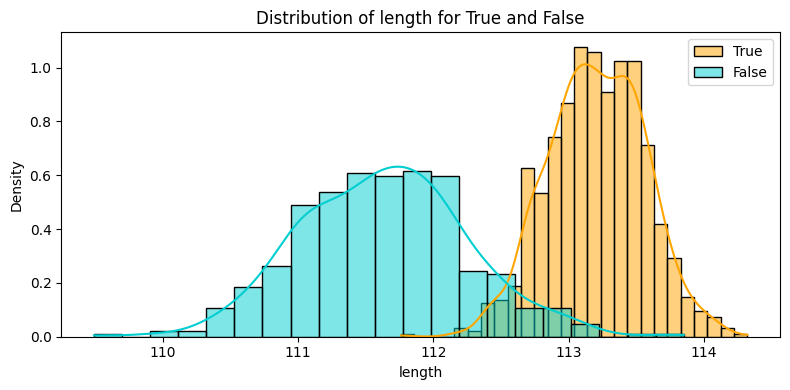

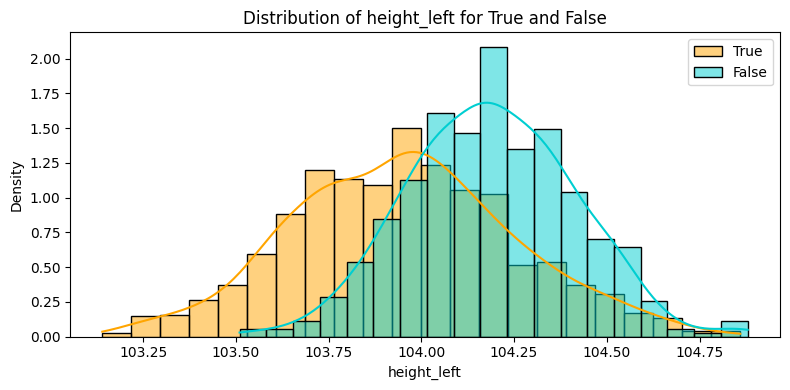

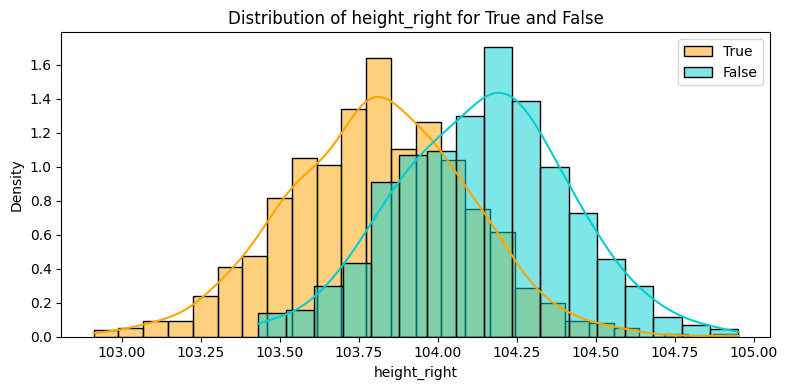

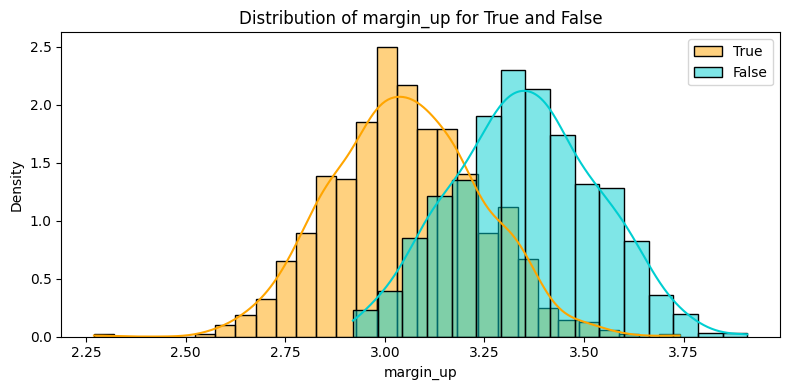

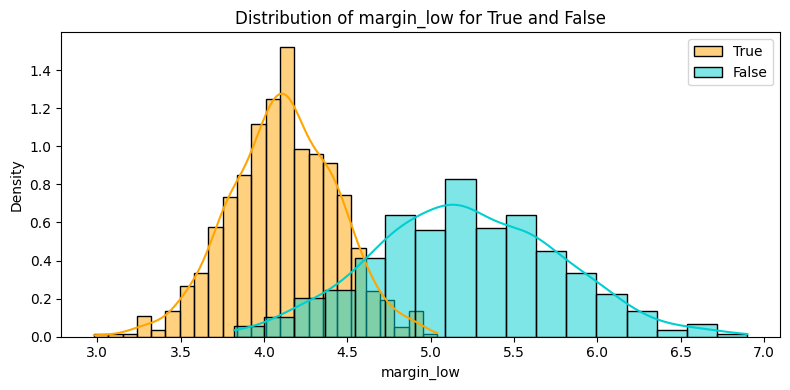

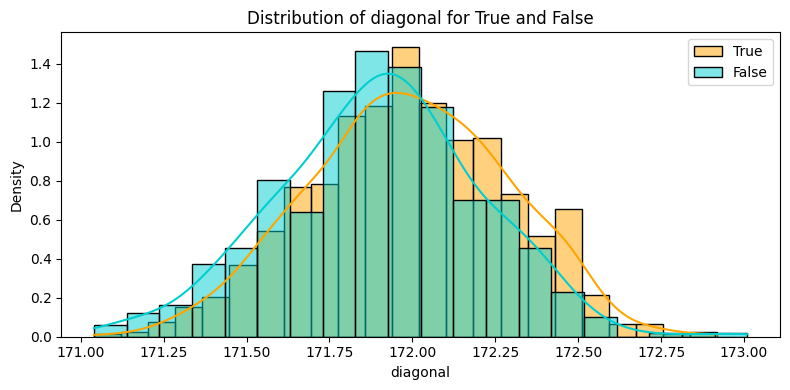

In [63]:
cols = ["length", "height_left", "height_right", "margin_up", "margin_low", "diagonal"]

for col in cols:                                      # pour chaque colonne de la liste
    plt.figure(figsize=(8, 4))                        # créer une nouvelle figure pour chaque histogramme
    sns.histplot(df[df["is_genuine"] == True][col],   # sélection des données où is_genuine est True
                 color="#FFA500",                   # couleur dorée pour les billets authentiques
                 label="True",                        # étiquette pour la légende
                 kde=True,                            # ajouter une courbe de densité (Kernel Density Estimate)
                 stat="density",                      # normaliser l'histogramme pour obtenir une densité
                 alpha=0.5)                           # transparence pour mieux voir les deux distributions
    
    sns.histplot(df[df["is_genuine"] == False][col], 
                 color="#00CED1", 
                 label="False", 
                 kde=True, 
                 stat="density", 
                 alpha=0.5)
    plt.title(f"Distribution of {col} for True and False")
    plt.xlabel(col)                                   # étiquette de l'axe X avec le nom de la variable
    plt.ylabel("Density")                             # étiquette de l'axe Y pour indiquer qu'il s'agit d'une densité
    plt.legend()                                      # afficher la légende pour différencier les classes
    plt.tight_layout()                                # ajuster automatiquement les sous-graphes pour éviter le chevauchement
    plt.show()                                        # afficher le graphique

# La densité sur l'axe Y, au lieu du nombre absolu de valeurs, est pratique pour comparer les formes 
# de distribution. Il s'agit de la « fréquence » relative d'apparition des valeurs, rapportée à la surface 
# totale du graphique, égale à 1. Si stat="count", l'axe Y représentera le nombre d'objets qui se trouvent 
# dans chaque colonne (par exemple, 50 billets de 113 cm de long). Si stat="density", l'axe Y représentera 
# la fréquence d'apparition de cette plage de valeurs par rapport à l'ensemble des données, et la somme 
# des aires de toutes les colonnes sera égale à 1.

**Interprétation des distributions :**

* **LENGHT :** les billets authentiques sont en moyenne plus longs que les contrefaçons. Leurs distributions se chevauchent à peine - la plupart des billets authentiques sont plus longs que la plupart des contrefaçons. Ainsi, la longueur permet de bien distinguer les deux catégories. Cette caractéristique sera utile pour la construction d'un modèle d'apprentissage automatique, car elle permet une distinction très nette entre les deux. En définitive, la longueur d'un billet est un indicateur fiable de son authenticité. Plus les deux distributions se chevauchent peu, plus il est facile pour l'algorithme de distinguer les billets authentiques des contrefaçons grâce à cette caractéristique.

* **HEIGHT LEFT :** les distributions se chevauchent partiellement, mais leurs pics (valeurs de densité maximale) se situent à des endroits différents : à gauche des billets authentiques et à droite des faux. Autrement dit, la hauteur gauche permet également de distinguer les classes, mais moins nettement que la longueur : il existe une zone où les valeurs de hauteur gauche sont communes aux deux groupes. Plus le chevauchement est faible, meilleure est la caractéristique de classification. Ici, la caractéristique est utile, mais pas parfaite ; elle fournira des informations supplémentaires au modèle, notamment lorsqu'elle sera combinée à d'autres caractéristiques. En définitive, la hauteur gauche est une caractéristique informative, mais pour certains billets, il sera plus difficile de déterminer la classe sans ambiguïté à partir de cette caractéristique qu'à partir de la longueur.

* **HEIGHT RIGHT :** les pics de distribution sont à nouveau décalés : vers la gauche pour les billets authentiques et vers la droite pour les faux. Il existe une zone de chevauchement où les valeurs de hauteur à droite sont communes aux deux groupes, mais la plupart des billets authentiques présentent une hauteur plus faible à droite, tandis que les faux billets ont une hauteur plus importante. Plus les pics de distribution sont éloignés, meilleure est la distinction entre les classes. La caractéristique de hauteur à droite permet de distinguer les classes, mais elle n'est pas parfaite : pour certains billets, la classification est difficile à l'aide de cette caractéristique, notamment dans la zone de chevauchement. Par conséquent, elle constitue un bon critère complémentaire pour le modèle.

* **MARGIN UP :** les pics des distributions sont décalés : les billets authentiques se situent à gauche, les contrefaits à droite. Il existe un léger chevauchement, mais globalement, les valeurs de marge pour les billets contrefaits sont supérieures à celles des billets authentiques. Plus la valeur est proche de 3,5, plus le billet a de chances d'être contrefait ; plus elle est proche de 3,0, plus il a de chances d'être authentique. Cette caractéristique informative permet de distinguer les billets authentiques des billets contrefaits.

* **MARGIN LOW :** les pics de distribution sont décalés : les billets authentiques se situent à gauche, les contrefaits à droite. Il existe un léger chevauchement, mais globalement, les valeurs de marge supérieure pour les billets contrefaits sont plus élevées que celles des billets authentiques. Cela signifie que la marge supérieure est un bon indicateur pour distinguer les deux catégories : plus sa valeur est proche de 3,5, plus le billet a de chances d’être contrefait ; plus elle est proche de 3,0, plus il a de chances d’être authentique. C'est l'un des indicateurs les plus informatifs.

* **DIAGONAL :** les deux distributions sont très similaires dans leur forme et se recoupent largement. Les « pics » (maxima de densité) se trouvent presque au même endroit. Il n'y a pas de décalage évident d'une distribution par rapport à l'autre, comme c'était le cas pour les autres caractéristiques. Cela signifie qu'il est difficile de distinguer un billet authentique d'un faux sur la base de la caractéristique « diagonale » : la plupart des valeurs se retrouvent dans les deux groupes. Il s'agit donc d'un critère faible pour la classification, qui ne permet pratiquement pas de distinguer les classes, car les valeurs des billets authentiques et des faux billets se recoupent fortement. Ce critère ne peut être utile qu'en combinaison avec d'autres critères plus informatifs.

**Conclusion générale :**

* Les caractéristiques **les plus fortes** (qui permettent le mieux de distinguer les billets authentiques des faux) sont : length (longueur), margin_low (marge inférieure) et margin_up (marge supérieure). Pour ces caractéristiques, les distributions des deux classes sont bien séparées, avec un chevauchement minimal.

* Caractéristiques **moyennes** (séparent les classes, mais avec un chevauchement notable) : height_left (hauteur à gauche) et height_right (hauteur à droite). Pour ces caractéristiques, les « pics » de distribution sont décalés, mais il existe une zone où les valeurs se rejoignent pour les deux groupes.

* Caractéristique **faible** (ne distingue presque pas les classes) : diagonal (diagonale). Avec cette caractéristique, les distributions coïncident presque entièrement et il est difficile de distinguer un billet authentique d'un faux.

### 2.2.3. Visualisation des boxplots des indicateurs pour les classes True et False

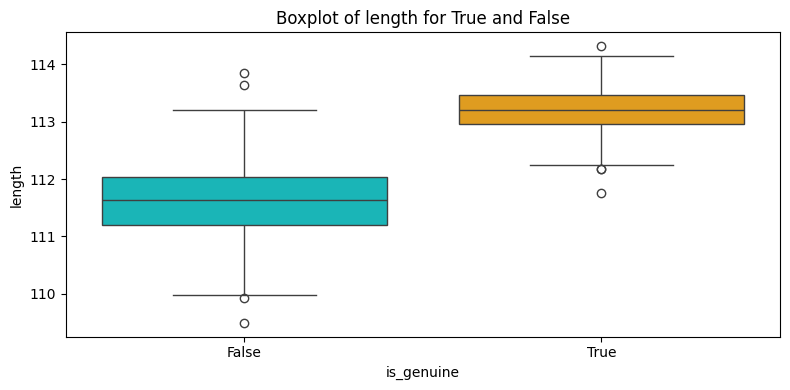

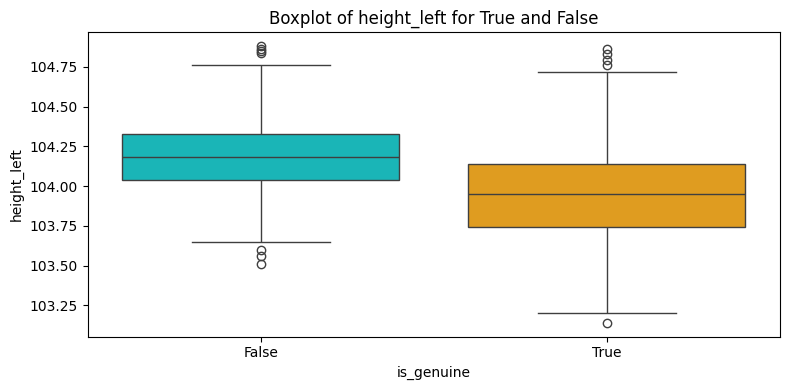

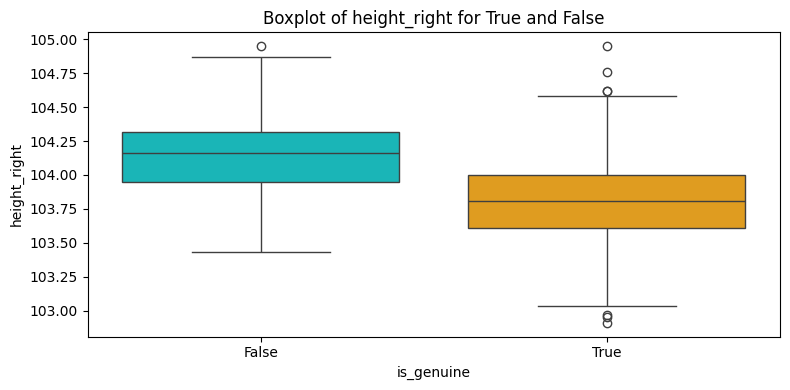

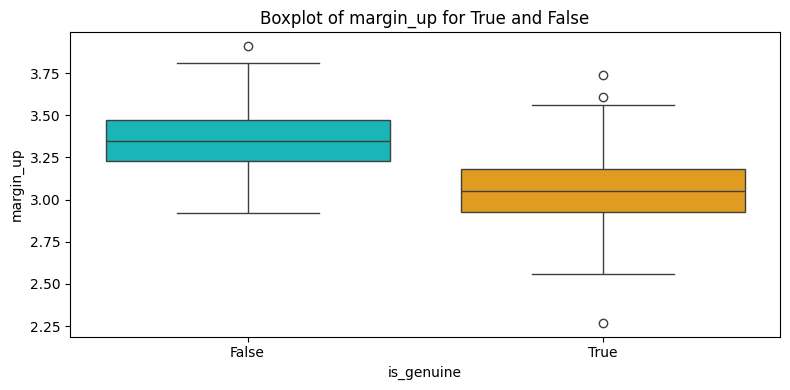

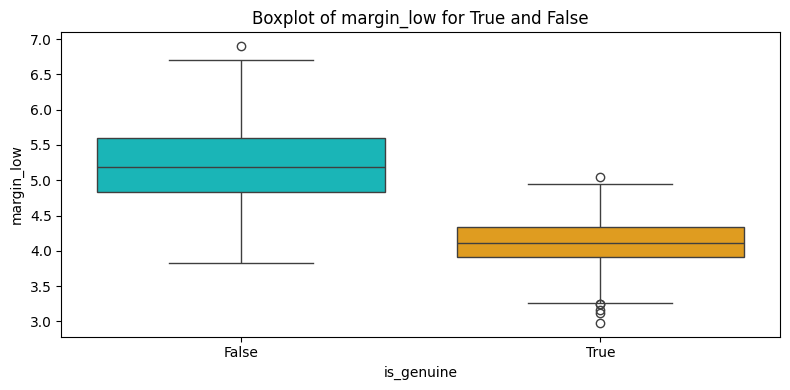

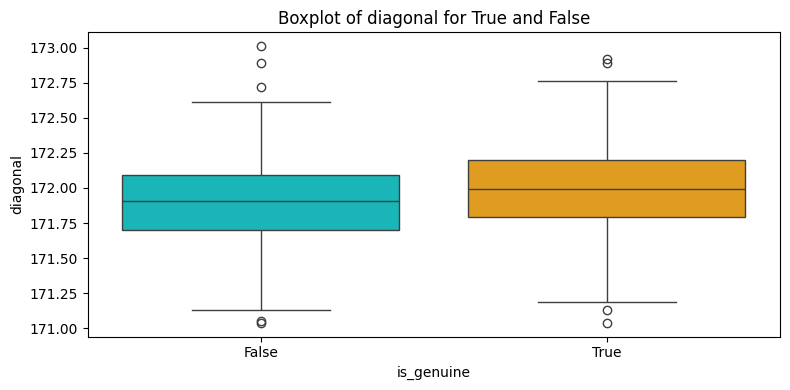

In [64]:
cols = ["length", "height_left", "height_right", "margin_up", "margin_low", "diagonal"]

for col in cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=col,                                    # variable à tracer sur l'axe Y
                x="is_genuine",                           # variable catégorielle à tracer sur l'axe X
                data=df,                                  # DataFrame contenant les données
                hue="is_genuine",                         # variable pour différencier les couleurs des boîtes (facultatif, ici on utilise la même que x)
                palette=["#00CED1", "#FFA500"],       # palette de couleurs pour les boîtes
                legend=False)                             # ne pas afficher la légende
    plt.title(f"Boxplot of {col} for True and False")     # titre du graphique pour indiquer quelle variable est représentée et les classes comparées
    plt.xlabel("is_genuine")                              # étiquette de l'axe X pour indiquer qu'il s'agit de la variable catégorielle
    plt.ylabel(col)                                       # étiquette de l'axe Y avec le nom de la variable
    plt.xticks([0, 1], ["False", "True"])                 # personnaliser les étiquettes de l'axe X pour afficher "False" et "True" au lieu de 0 et 1
    plt.tight_layout()                                    # ajuster automatiquement les sous-graphes pour éviter le chevauchement
    plt.show()                                            # afficher le graphique

**Interprétation des boxplotes :**

* **LENGHT :** la médiane de la longueur des billets authentiques est nettement supérieure à celle des faux billets. Les deux groupes présentent peu de chevauchement, ce qui fait de la longueur un critère très discriminant. Les valeurs des billets authentiques sont plus élevées et plus regroupées, tandis que les faux billets montrent une plus grande dispersion et quelques valeurs extrêmes (outliers).

* **HEIGHT LEFT :** la médiane est légèrement plus élevée pour les faux billets que pour les authentiques. Les deux distributions se chevauchent partiellement, mais on observe davantage de valeurs extrêmes (outliers) chez les deux classes. Cette caractéristique permet de distinguer les classes, mais la séparation est moins nette que pour la longueur.

* **HEIGHT RIGHT :** la médiane est plus élevée pour les faux billets que pour les authentiques. Les distributions présentent un certain chevauchement, mais la différence de médiane reste visible. Les deux classes montrent quelques valeurs extrêmes, surtout chez les authentiques. Cette variable aide à différencier les classes, mais la séparation est moins marquée que pour la longueur.

* **MARGIN UP :** la médiane est nettement plus élevée pour les faux billets que pour les authentiques. Les deux groupes se distinguent clairement, avec peu de chevauchement entre les distributions. Cette variable est donc très discriminante pour différencier les billets authentiques des contrefaçons. Quelques valeurs extrêmes sont présentes, surtout chez les authentiques.

* **MARGIN LOW :** la médiane est nettement plus élevée pour les faux billets que pour les authentiques. Les distributions des deux classes sont bien séparées, avec très peu de chevauchement. Cette variable est donc un excellent critère pour distinguer les billets authentiques des contrefaçons. Quelques valeurs extrêmes sont présentes, surtout chez les authentiques.

* **DIAGONAL :** la médiane est très similaire pour les deux classes, avec un fort chevauchement des distributions. Les valeurs typiques et la dispersion sont proches pour les billets authentiques et les faux, ce qui rend cette variable peu discriminante pour différencier les deux groupes. Quelques valeurs extrêmes sont présentes dans chaque classe.

**Conclusion générale :**

La plupart des caractéristiques **(length, margin_up, margin_low)** permettent de bien distinguer les billets authentiques des contrefaçons : leurs médianes et leurs étendues diffèrent significativement entre les deux classes, avec un chevauchement minimal. Les caractéristiques **height_left и height_right** permettent également de distinguer les classes, mais présentent un chevauchement plus important. La caractéristique **diagonale** ne permet guère de distinguer les classes : leurs distributions sont presque identiques. Par conséquent, la longueur, la marge supérieure et la marge inférieure sont les plus informatives pour la construction d’un modèle.

# 3. Analyse de corrélation

## 3.1. Corrélation  entre la variable cible et les indicateurs

Il faut créer une carte thermique de corrélation (heatmap) entre la variable cible (is_genuine) et les indicateurs à l'aide du coefficient de Spearman. Cela permettra de déterminer les indicateurs les plus fortement liés à la variable cible.

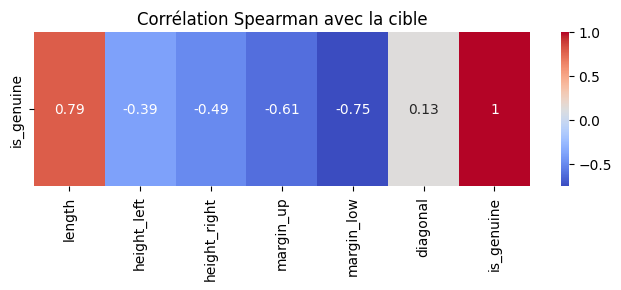

In [65]:
import seaborn as sns

X = df[["length", "height_left", "height_right", "margin_up", "margin_low", "diagonal"]]
y = df["is_genuine"]

df_corr = X.copy()                              # creer une copie de X pour éviter de modifier les données d'origine
df_corr['is_genuine'] = y                       # ajouter la colonne cible "is_genuine" à la copie de X pour pouvoir calculer les corrélations avec la cible
corr_matrix = df_corr.corr(method='spearman')   # calculer les corrélations de Spearman
plt.figure(figsize=(8, 2))                      # définir la taille de la figure pour que le graphique soit plus large que haut
sns.heatmap(corr_matrix[['is_genuine']].T,      # sélectionner uniquement la ligne de corrélations avec la cible "is_genuine" et la transposer pour l'afficher horizontalement
            annot=True,                         # afficher les valeurs de corrélation dans les cellules
            cmap='coolwarm')                    # utiliser une palette de couleurs pour différencier les corrélations positives (rouge) et négatives (bleu)
plt.title('Corrélation Spearman avec la cible')
plt.show()

* **length (0,79) :** forte corrélation positive. Plus la longueur est importante, plus la probabilité que le billet soit authentique est élevée.
* **margin_low (-0,75) :** forte corrélation négative. Plus la marge inférieure est faible, plus la probabilité que le billet soit authentique est élevée.
* **margin_up (-0,61) :** corrélation négative modérée. Une marge supérieure plus petite indique plus souvent un billet authentique.
* **height_right (-0,49) :** corrélation négative modérée. Une hauteur plus petite à droite indique plus souvent un billet authentique.
* **height_left (-0,39) :** faible corrélation négative. Une hauteur inférieure à gauche indique plus souvent un billet authentique.
* **diagonal (0,13) :** très faible corrélation positive. Ce critère n'est pratiquement pas lié à l'authenticité.

**Conclusion :** les caractéristiques les plus informatives pour déterminer l'authenticité sont : length, margin_low, margin_up. La caractéristique diagonal n'aide pratiquement pas à distinguer les classes. Le signe de corrélation indique la direction : positif - plus la caractéristique augmente, plus la probabilité d'un billet authentique augmente, négatif - au contraire.

## 3.2. Corrélation entre toutes les  indicateurs

Il faut créer une carte thermique de corrélation entre toutes les  indicateurs afin d'identifier les paires de  indicateurs présentant une forte corrélation mutuelle (multicollinéarité). Si deux indicateurs sont très fortement corrélés (par exemple, >0,8 ou <-0,8), l'un d'eux peut être exclu afin d'éviter la multicolinéarité.

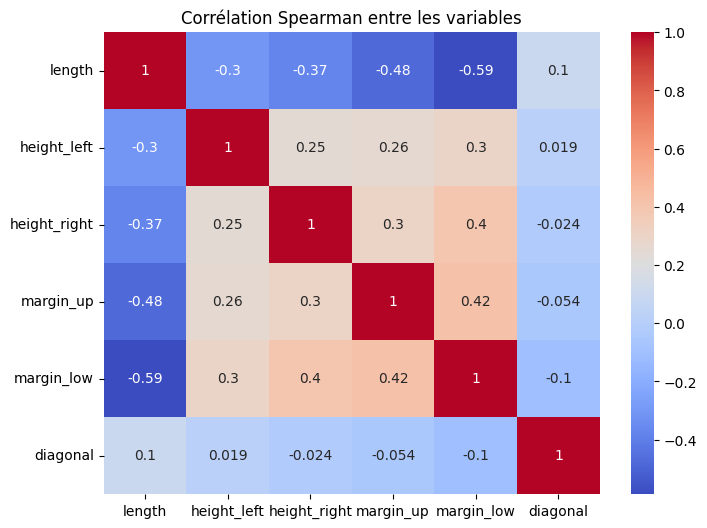

In [66]:
corr_features = X.corr(method='spearman')               # calculer les corrélations de Spearman entre les variables d'entrée (sans la cible)
plt.figure(figsize=(8, 6))                            
sns.heatmap(corr_features,                              # afficher la matrice de corrélation complète entre les variables d'entrée
            annot=True,                                 # afficher les valeurs de corrélation dans les cellules
            cmap='coolwarm')                            # utiliser une palette de couleurs pour différencier les corrélations positives (rouge) et négatives (bleu)
plt.title('Corrélation Spearman entre les variables')
plt.show()

* La corrélation négative la plus forte : length et margin_low (-0,59). Cela signifie que plus la longueur est grande, plus margin_low est faible, et inversement.

* Les autres corrélations entre les caractéristiques sont modérées ou faibles (de -0,5 à 0,4). Cela signifie que la plupart des caractéristiques véhiculent des informations différentes.

* Globalement, ces données ne contiennent pas de paires de caractéristiques présentant une corrélation très élevée (module > 0,8), toutes les caractéristiques peuvent donc être conservées.

# 4. Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement. À cette étape, les données sources sont préparées pour ML :

1. Les indicateurs explicatifs cible sont extraites (on distingue les indicateurs (X) et la variable cible (y) : toutes les valeurs numériques sont utilisées comme indicateurs, et la colonne is_genuine est utilisée comme variable cible (billet authentique ou faux))

2. Les données sont divisées en ensembles d'entraînement et de test (pour tester les performances d'un modèle entraîné sur un ensemble de données de test sur un nouvel ensemble de données)

3. Une normalisation des caractéristiques est effectuée (pour garantir que toutes les caractéristiques soient à la même échelle. Ceci est important pour que les algorithmes d'apprentissage automatique puissent comparer correctement les valeurs des différentes caractéristiques et ne pas privilégier celles dont l'étendue numérique est plus grande)

Cette étape est nécessaire pour garantir un entraînement efficace des algorithmes d'apprentissage automatique et des prédictions précises.

## 4.1. Séparation des indicateurs explicatifs et de la cible

In [70]:
# Toutes les colonnes numériques caractéristiques sont utilisées comme indicateurs explicatifs (X)
X = df[["length", "height_left", "height_right", "margin_up", "margin_low", "diagonal"]]  
y = df["is_genuine"]  # La colonne cible (vrai ou faux)

#  vérification du résultat de la séparation
print("X shape:", X.shape)                    # affiche le nombre de lignes et de colonnes de X          
print("y shape:", y.shape)                    # affiche le nombre de lignes de y (doit être égal à celui de X)
print("\nAperçu de X:")                       
print(X.head())                               # affiche les 5 premières lignes de X pour vérifier que les bonnes colonnes ont été sélectionnées
print("\nAperçu de y:")
print(y.head())                               # affiche les 5 premières lignes de y pour vérifier que la colonne cible est correcte

X shape: (1463, 6)
y shape: (1463,)

Aperçu de X:
   length  height_left  height_right  margin_up  margin_low  diagonal
0  112.83       104.86        104.95       2.89        4.52    171.81
1  113.09       103.36        103.66       2.99        3.77    171.46
2  113.16       104.48        103.50       2.94        4.40    172.69
3  113.51       103.91        103.94       3.01        3.62    171.36
4  112.54       104.28        103.46       3.48        4.04    171.73

Aperçu de y:
0    True
1    True
2    True
3    True
4    True
Name: is_genuine, dtype: bool


## 4.2. Division des données en ensembles d'entraînement et de test

In [71]:
from sklearn.model_selection import train_test_split

# train_test_split divise aléatoirement X et y en deux parties :
# - X_train, y_train: pour l'entraînement du modèle
# - X_test, y_test: pour la validation du modèle
X_train, X_test, y_train, y_test = train_test_split(
    X, y,               # les données à diviser (X et y)
    test_size=0.2,      # 20 % des données serviront aux tests, 80 % à l'entraînement
    random_state=7,     # randomisation pour la reproductibilité du résultat
    stratify=y)         # сonserver les proportions de classes (Vrai/Faux) identiques à celles des données d'origine

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# Le paramètre random_state définit un chiffre fixe pour le générateur de nombres aléatoires, 
# à partir duquel commence la séquence de nombres aléatoires.  Ceci est important pour la reproductibilité 
# des expériences : avec un random_state identique, le fractionnement des données, les échantillons aléatoires 
# et les résultats seront identiques à chaque exécution du code. S'il n'est pas spécifié, les résultats 
# seront différents à chaque exécution, ce qui rendra difficile la vérification et la comparaison des modèles.

# Le paramètre stratify=y garantit que le ratio des classes True et False pour la variable cible y dans 
# les ensembles d'apprentissage et de test sera le même que dans les données d'origine. Il est important que 
# les deux ensembles soient représentatifs et contiennent la même proportion de chaque classe. Sans stratify, 
# il est possible que l'un des échantillons contienne trop peu ou pas du tout d'objets d'une certaine classe, 
# ce qui détériorerait la qualité de l'apprentissage et de l'évaluation du modèle.

X_train shape: (1170, 6)
X_test shape: (293, 6)
y_train shape: (1170,)
y_test shape: (293,)


## 4.3. Standartisation des données

La standardisation est effectuée après la division en ensembles d'apprentissage et de test afin d'éviter toute fuite d'informations (data leakage). Si l'on standardise d'abord toutes les données, puis que l'on divise en train/test, les paramètres de mise à l'échelle (moyenne et écart type) seront calculés en tenant compte de l'échantillon de test. Cela conduirait à une « fuite » des informations du test vers l'apprentissage, et l'évaluation du modèle serait alors biaisée. C'est pourquoi on divise d'abord les données, puis on calcule les paramètres de standardisation uniquement sur l'échantillon d'apprentissage et on les applique aux deux parties. Ainsi, l'échantillon de test reste « invisible » pour les étapes d'apprentissage et d'évaluation du modèle.

**StandardScaler** est une fonction qui ramène toutes les caractéristiques numériques à une seule échelle : après traitement, chaque caractéristique a une moyenne de 0 et un écart type de 1. Formule : la moyenne de l'échantillon d'apprentissage est soustraite de chaque valeur et divisée par l'écart type. Cette approche aide les algorithmes d'apprentissage automatique à fonctionner correctement, en particulier si les caractéristiques ont initialement des échelles différentes. Il fonctionne bien si les caractéristiques ont une distribution à peu près normale et s'il n'y a pas d'écarts importants. Cette méthode de normalisation convient à la plupart des algorithmes d'apprentissage automatique (régression logistique, SVM, KNN, etc.).

In [72]:
from sklearn.preprocessing import StandardScaler 
# formule = (x - mean) / std 
# de chaque valeur est soustraite la moyenne, puis le résultat est divisé par l'écart type

scaler = StandardScaler()                       # crée un objet à partir de la bibliothèque sklearn

# entraîner le standardiseur sur l'échantillon d'apprentissage X_train 
# (calculer la moyenne et l'écart type pour chaque caractéristique 
# uniquement à partir des données d'apprentissage) et appliquer 
# la standardisation à X_train (pour chaque valeur de caractéristique, 
# la formule suivante est appliquée : (x - mean) / std))
X_train_scaled = scaler.fit_transform(X_train)

# applique la normalisation à l'échantillon test X_test en utilisant 
# les paramètres (moyenne et écart type) qui ont été calculés 
# sur l'échantillon d'apprentissage X_train
X_test_scaled = scaler.transform(X_test)        

# X_train_scaled et X_test_scaled ils peuvent être utilisés pour l'entraînement et le test des modèles

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jeu d'entraînement après la standardisation :")
print("Moyenne X_train_scaled:", np.round(X_train_scaled.mean(axis=0), 3))
print("Écart type X_train_scaled:", np.round(X_train_scaled.std(axis=0), 3))

print()

print("Jeu de test après la standardisation :")
print("Moyenne X_test_scaled:", np.round(X_test_scaled.mean(axis=0), 3))
print("Écart type X_test_scaled:", np.round(X_test_scaled.std(axis=0), 3))

Jeu d'entraînement après la standardisation :
Moyenne X_train_scaled: [ 0. -0. -0.  0. -0. -0.]
Écart type X_train_scaled: [1. 1. 1. 1. 1. 1.]

Jeu de test après la standardisation :
Moyenne X_test_scaled: [-0.026 -0.097  0.042 -0.048 -0.06  -0.092]
Écart type X_test_scaled: [0.975 0.931 1.01  1.053 1.    1.048]


# 5. Test des algorithmes

**APPROCHE NON SUPERVISE :** est utilisé lorsqu'il n'y a pas de marques de classe (pas d'informations permettant de distinguer les faux des originaux). L'objectif de cette approche est de comprendre la structure des données, d'identifier les groupes cachés et de vérifier dans quelle mesure les caractéristiques permettent à elles seules de distinguer les classes.

* **K-means :** un algorithme de regroupement qui ne nécessite pas d'étiquettes de classes (Vrai / Faux). Il permet de déterminer s'il est possible de diviser les données en groupes (clusters) uniquement sur la base de caractéristiques, sans savoir s'il s'agit d'une contrefaçon ou d'un original. Il est possible de comparer les clusters trouvés avec les étiquettes réelles et d'évaluer dans quelle mesure les caractéristiques permettent de distinguer les contrefaçons des originaux.

**APPROCHE SUPERVISE :** est utilisé lorsqu'il existe des étiquettes de classes (vous savez où se trouve la contrefaçon et où se trouve l'original). L'objectif de cette approche est d'apprendre au modèle à prédire la classe à partir de caractéristiques et d'évaluer la qualité des prédictions.

* **Régression logistique :** modèle classique pour la classification binaire (Vrai / Faux). Il fournit un modèle simple et interprétable : il est possible de comprendre quelles caractéristiques sont les plus importantes pour déterminer la classe. Il s'apprend rapidement et fonctionne bien sur des données standardisées.

* **KNN :** classe l'objet selon les classes des objets les plus proches dans l'échantillon d'apprentissage. Il ne nécessite pas d'apprentissage, mais est sensible à l'échelle des caractéristiques (il doit être testé sur des données standardisées). Ce modèle est adapté aux tâches où les classes sont bien distinctes.

* **Random Forest :** un algorithme qui construit de nombreux « arbres de décision » (règles simples du type « si la longueur est supérieure à X, alors... »). Il offre une grande précision, résiste aux anomalies et ne nécessite pas de réglage poussé des caractéristiques. Il aide à mettre en évidence l'importance des caractéristiques et fonctionne bien même lorsque les relations entre elles sont complexes.

## 5.1. K-means

1. Nous commençons par appliquer la méthode du coude sur les données d’entraînement standardisées afin d’estimer le nombre optimal de clusters. Nous calculons l'inertie pour chaque k - l'inertie mesure la proximité des points par rapport au centre de leur cluster.

2. Nous validons ensuite ce choix avec le score de silhouette, qui permet de mesurer la qualité de la séparation entre les clusters. Cela nous aide à confirmer que deux clusters constituent bien la solution la plus pertinente.

3. Une fois le nombre de clusters fixé, nous entraînons le modèle K-means sur les données d’entraînement standardisées avec k=2. Le modèle attribue alors chaque observation à l’un des deux clusters identifiés.

4. Nous visualisons ensuite les clusters et leurs centroïdes dans un espace réduit à deux dimensions grâce à l’ACP. Cette représentation permet d’observer plus facilement la séparation entre les groupes.

5. Nous comparons ensuite les clusters obtenus aux classes réelles afin de comprendre à quelle classe correspond chaque cluster. Cette étape est nécessaire, car K-means produit des numéros de clusters, et non directement les étiquettes True/False.

6. Enfin, nous construisons une matrice de confusion pour évaluer la qualité de cette correspondance sur les données de test. Elle permet de mesurer les bonnes prédictions et les erreurs, en particulier les faux billets mal détectés.

### 5.1.1. Choix du nombre de clusters: méthode du coude

L'attribut `inertia_` est intégré à KMeans et stocke la somme des carrés des distances de chaque point à son centroïde. Plus sa valeur est faible, plus les clusters sont compacts. Nous exécutons KMeans 10 fois avec différentes valeurs de `k`, en enregistrant l'inertie à chaque fois.  Chaque groupe possède son propre centre, ou centroïde, et chaque point est positionné par rapport au centroïde le plus proche. L'inertie mesure la distance entre chaque point et son centroïde. Ces distances sont ensuite élevées au carré et additionnées (1.pour "pénaliser" davantage les points éloignés, 2. pour rendre toutes les valeurs positives). Si l'inertie est faible, les points sont proches de leur centre et les groupes sont compacts ; si l'inertie est élevée, les points sont plus dispersés et les groupes sont moins compacts.

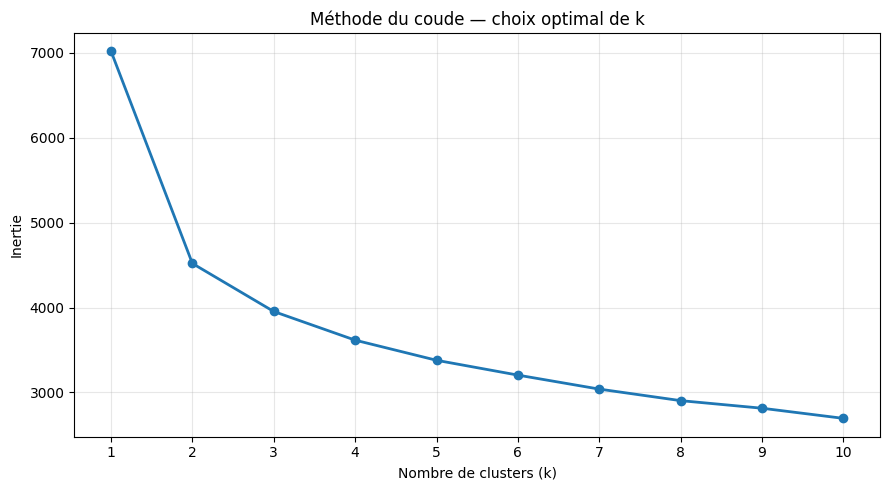

In [73]:
# La méthode du coude permet de déterminer le nombre optimal de clusters
# On teste différents nombres de clusters (de 1 à 10) et on mesure la "compacité" de chaque solution

from sklearn.cluster import KMeans 

# Créer une liste vide : pour les valeurs d'inertie de chaque k
inertia_values = []

for k in range(1, 11):                              # boucle k de 1 à 10 (on teste différents nombres de clusters)
    model = KMeans(                                 # créer un modèle avec k clusters
        n_clusters=k,                               # combien de clusters faut-il trouver
        random_state=39)                            # capture l'aléatoire afin que le résultat soit identique à chaque exécution                      
    
    # model.fit() - fonction d'entraînement 
    # du modèle sur les données d'entrée
    model.fit(X_train_scaled)                       # entraîner le modèle sur le X_train_scaled
    
    # model.inertia_ - prendre la valeur 
    # actuelle de l'inertie du modèle
    # ajouter cette valeur à la liste 
    # des valeurs d'inertie
    inertia_values.append(model.inertia_)           # enregistrer l'inertie (somme des carrés des distances au centroïde)

# créer un graphique pour visualiser 
#  les valeurs d'inertie en fonction de k
plt.figure(figsize=(9, 5))                          # taille du graphique
plt.plot(range(1, 11),                              # axe X : nombre de clusters de 1 à 10
         inertia_values,                            # axe Y : les valeurs d'inertie correspondantes
         marker='o',                                # marqueur pour les points de chaque k
         linewidth=2)                               # largeur de la ligne
plt.xlabel('Nombre de clusters (k)')                # étiquette de l'axe X
plt.ylabel('Inertie')                               # étiquette de l'axe Y
plt.title('Méthode du coude — choix optimal de k')  # titre
plt.xticks(range(1, 11))                            # marques sur l'axe X: 1, 2, 3, ..., 10
plt.grid(True, alpha=0.3)                           # grille légère pour faciliter la lecture
plt.tight_layout()                                  # pour que les étiquettes ne soient pas coupées
plt.show() 

Le graphique montre comment l'inertie (compacité des clusters) diminue avec l'augmentation du nombre de clusters. **Le "coude"** est l'endroit où la courbe commence à s'aplatir. C'est le point optimal : ajouter plus de clusters n'améliore pas significativement la compacité. Dans notre cas, on devrait voir un coude à k=2, ce qui confirme qu'il y a bien 2 groupes distincts (vrais et faux billets). Car le coude est clair à k=2, cela signifie que nos données se divisent naturellement en 2 groupes bien distincts, ce qui correspond parfaitement à notre problème (vrai vs faux).

### 5.1.2. Validation avec le score de silhouette

Le score de silhouette mesure la qualité de la clusterisation. Il varie de -1 à 1 :
* proche de 1 : les objets sont bien groupés dans leur cluster et loin des autres clusters (excellent)
* proche de 0 : les objets sont à la frontière entre clusters (ambigu)
* négatif : les objets sont peut-être dans le mauvais cluster (mauvais)

La méthode du coude ne fournit qu'une hypothèse préliminaire : il semblerait que la meilleure option soit deux clusters. Le score de silhouette est précisément nécessaire pour tester cette hypothèse : les clusters sont-ils réellement mieux séparés pour k = 2 que pour k = 3, k = 4, etc. ? Autrement dit :

* Premièrement, la méthode du coude suggère que k = 2 est possible
* Ensuite, le score de silhouette compare plusieurs valeurs de k et détermine laquelle offre la meilleure qualité de clustering
* Si le score de silhouette maximal est également obtenu pour k = 2, alors le choix est confirmé par les deux méthodes

**Même si la méthode du coude suggère k=2, on teste plusieurs valeurs de k avec le score de silhouette pour vérifier que 2 est bien le meilleur choix.**

In [74]:
# silhouette_score calcule le score de silhouette moyen
# silhouette_samples calcule le score de silhouette pour chaque observation
from sklearn.metrics import silhouette_score, silhouette_samples 
import numpy as np

# creer liste pour stocker les scores de silhouette pour différents k
silhouette_scores = []                                         

for k in range(2, 11):                                         # tester de 2 à 10 clusters (silhouette nécessite au moins 2 clusters)
    kmeans_temp = KMeans(n_clusters=k,                         # combien de clusters à analyser            
                         random_state=39)                      # capture l'aléatoire pour que le résultat soit identique à chaque exécution           
    
    # entraîner le modèle et obtenir les étiquettes de cluster 
    # pour chaque observation de X_train_scaled
    cluster_labels = kmeans_temp.fit_predict(X_train_scaled)   
    
    silhouette_avg = silhouette_score(                         # calculer le score de silhouette moyen
        X_train_scaled,                                        # les données d'entrée
        cluster_labels)                                        # les étiquettes de cluster pour chaque observation
    
    # enregistrer le score de silhouette moyen pour ce k  
    silhouette_scores.append(silhouette_avg)                   

    # afficher le score de silhouette pour ce k avec 3 décimales
    print(f"Pour k={k}, le score est : {silhouette_avg:.3f}")  

Pour k=2, le score est : 0.344
Pour k=3, le score est : 0.213
Pour k=4, le score est : 0.201
Pour k=5, le score est : 0.158
Pour k=6, le score est : 0.147
Pour k=7, le score est : 0.146
Pour k=8, le score est : 0.142
Pour k=9, le score est : 0.136
Pour k=10, le score est : 0.139


### 5.1.3. Création de clusters et lancement de l'algorithme

In [75]:
# Créer un modèle KMeans avec 2 clusters 
# random_state=39 pour assurer que les centres initiaux 
# des clusters seront les mêmes à chaque exécution
kmeans = KMeans(n_clusters=2, random_state=39)

# Lancer un algorithme de clustering qui recherche deux centres (clusters) dans les données
# le modèle « mémorise » les coordonnées des centres des clusters 
# et peut attribuer les nouveaux objets à l'un d'entre eux
kmeans.fit(X_train_scaled)

# Utiliser le modèle KMeans déjà formé pour définir à quel cluster appartient chaque objet 
# de l'ensemble de données de test X_test_scaled
clusters_test = kmeans.predict(X_test_scaled)

# Afficher les 20 premiers résultats pour voir à quel cluster chaque billet a été assigné
print("Clusters prédits pour les 20 premiers billets du test :", clusters_test[:20])

Clusters prédits pour les 20 premiers billets du test : [0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0]


### 5.1.4. Visualisation des clusters et des centroïdes

Visualisation des clusters en 2D avec ACP (réduction de dimensions) est la solution optimale. Problème principale : nous avons 6 dimensions (6 caractéristiques), mais on ne peut visualiser qu'en 2D. Donc solution : utiliser ACP pour projeter les 6 dimensions en 2 dimensions principales. L'ACP prend les 6 caractéristiques originales et construit de nouveaux axes à partir de celles-ci, préservant au mieux les différences entre les objets.

* L'algorithme analyse les directions dans lesquelles les données varient le plus
* Il positionne le premier nouvel axe là où la dispersion est la plus importante
* Il positionne le second axe dans une direction différente et indépendante, où le maximum d'informations est également préservé
* Ensuite, chaque point des six caractéristiques est converti en coordonnées sur ces deux nouveaux axes

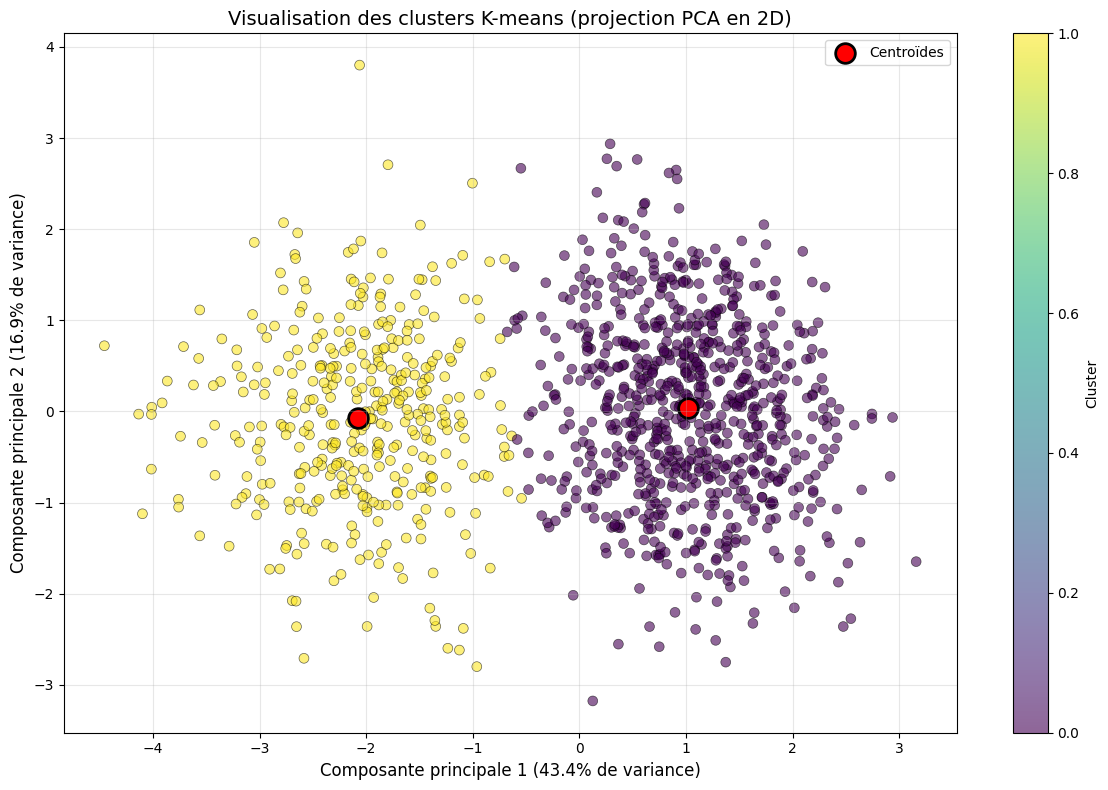

Variance expliquée par les 2 composantes principales : 60.2%


In [76]:
from sklearn.decomposition import PCA

# Créer un objet PCA pour réduire à 2 dimensions
pca = PCA(n_components=2, random_state=39)

# Transformer les données d'entraînement en 2 dimensions
X_train_pca = pca.fit_transform(X_train_scaled)

# Transformer les centres des clusters (centroïdes) en 2 dimensions aussi
# kmeans.cluster_centers_ contient les coordonnées des 2 centres dans l'espace à 6 dimensions
centers_pca = pca.transform(kmeans.cluster_centers_)

# Obtenir les labels de clusters pour l'ensemble d'entraînement
clusters_train = kmeans.predict(X_train_scaled)

# Créer la visualisation
plt.figure(figsize=(12, 8))

# Dessiner les points colorés selon leur cluster
scatter = plt.scatter(X_train_pca[:, 0],           # coordonnée X (première composante principale)
                      X_train_pca[:, 1],           # coordonnée Y (deuxième composante principale)
                      c=clusters_train,            # couleur selon le cluster (0 ou 1)
                      cmap='viridis',              # palette de couleurs prête à l'emploi dans matplotlib
                      alpha=0.6,                   # transparence
                      s=50,                        # taille des points
                      edgecolors='black',          # bordure noire
                      linewidths=0.5)              # épaisseur de la bordure des points

# Dessiner les centroïdes (centres des clusters)
plt.scatter(centers_pca[:, 0],                     # coordonnée X des centroïdes
            centers_pca[:, 1],                     # coordonnée Y des centroïdes
            c='red',                               # couleur rouge
            marker='o',                            # forme : cercle
            s=200,                                 # taille plus grande
            edgecolors='black',                    # bordure noire
            linewidths=2,                          # bordure épaisse
            label='Centroïdes')                    # étiquette pour la légende

  
# pca.explained_variance_ratio_ est un tableau qui stocke la proportion de variance expliquée pour chaque composante principale
plt.xlabel(f'Composante principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)', fontsize=12)
plt.ylabel(f'Composante principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)', fontsize=12)
plt.title('Visualisation des clusters K-means (projection PCA en 2D)', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variance expliquée par les 2 composantes principales : {pca.explained_variance_ratio_.sum()*100:.1f}%")

Une visualisation par cluster est nécessaire pour vérifier visuellement dans quelle mesure l'algorithme K-means a bien divisé les données, où se situent les centroïdes et s'il existe un chevauchement entre les groupes. Cela signifie que les deux composantes principales ont conservé environ 60 % de l'information contenue dans les six caractéristiques initiales. Par conséquent, ce graphique reflète assez fidèlement la réalité.

### 5.1.5. Aperçu des clasters

Dans ce bloc, nous vérifions dans quelle mesure les clusters trouvés par l'algorithme sont similaires aux classes réelles. L'algorithme K-means ne distingue pas les valeurs vraies des valeurs fausses ; il fournit uniquement des numéros de cluster. Ce tableau nous aide à identifier la classe réelle à laquelle chaque cluster correspond. Si la quasi-totalité des valeurs vraies se trouvent dans un cluster et la quasi-totalité des valeurs fausses dans un autre, le clustering est alors efficace.

In [77]:
# Créer une table de comparaison entre les vraies étiquettes y_test et les clusters prédits clusters_test

table = pd.crosstab(              # pd.crosstab crée une table de contingence pour comparer deux séries de données
    y_test,                       # y_test : réelles étiquettes (True/False)            
    clusters_test,                # clusters_test : 0/1 clusters trouvés par K-means
    rownames=['is_genuine'],      # nom de la ligne pour la table de contingence
    colnames=['Cluster'])         # nom de la colonne pour la table de contingence
print(table)

Cluster       0   1
is_genuine         
False         3  96
True        190   4


Le tableau montre qu'un groupe est principalement composé de vrais billets et l'autre principalement de faux billets, ce qui signifie que l'algorithme K-means a bien séparé les données, même sans connaître les étiquettes réelles. 

Mais K-means ne connaît pas True/False et il donne seulement 0 ou 1. On regarde le tableau crosstab ci-dessus pour savoir quel numéro 
correspond à quelle classe, puis on traduit manuellement. D'après notre crosstab cluster 0 contient les billets vrais (True), et cluster 1 contient les billets faux (False).

In [78]:
# Convertir les clusters 0/1 en classes réelles True/False

# clusters_test : résultat de l'algorithme K-means exécuté sur les données de test
# pd.Series(clusters_test) : convertit une liste ou un tableau en un objet pandas (colonne de données)
#    afin qu'il puisse être facilement utilisé avec .map()
# .map({0: True, 1: False}) : remplace les valeurs 0 par True et les valeurs 1 par False
#    c'est le dictionnaire des valeurs de remplacement
kmeans_pred = pd.Series(clusters_test).map({0: True, 1: False})

# Tableau de comparaison entre les vraies classes et les classes prédites après conversion
table_kmeans_pred = pd.crosstab(
    y_test.reset_index(drop=True),   # vraies étiquettes
    kmeans_pred,                     # prédictions K-means après conversion
    rownames=["Réel"],               # nom de la ligne pour la table de contingence
    colnames=["Prédit"]              # nom de la colonne pour la table de contingence
)

print(table_kmeans_pred)             # afficher la table de contingence pour évaluer les performances du clustering après conversion

Prédit  False  True 
Réel                
False      96      3
True        4    190


### 5.1.6. Matrice de confusion

La matrice de confusion compare les vraies étiquettes (y_test) avec les prédictions du modèle (kmeans_pred). Elle montre combien d'erreurs il y a et de quel type. Elle est particulièrement utile dans notre projet, car nous voulons repérer un maximum de faux billets et limiter les cas où un faux billet serait classé comme vrai.

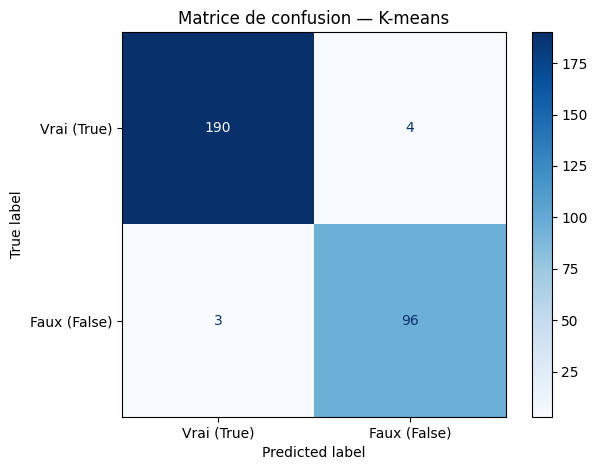


Nombre de faux billets NON détectés (FN) : 3
Nombre de vrais billets mal classés (FP) : 4


In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_kmeans = confusion_matrix(                        # calculer la matrice de confusion
    y_test,                                          # les vraies étiquettes (True/False)
    kmeans_pred,                                     # les prédictions K-means converties
    labels=[True, False])                            # ordre des classes sur le graphique

disp = ConfusionMatrixDisplay(                       # créer un objet pour afficher la matrice de confusion
    confusion_matrix=cm_kmeans,                      # la matrice de confusion calculée précédemment
    display_labels=["Vrai (True)", "Faux (False)"])  # étiquettes lisibles

disp.plot(cmap="Blues")                              # palette de couleurs bleue
plt.title("Matrice de confusion — K-means")          # titre du graphique
plt.tight_layout()                                   # ajuster automatiquement les sous-graphes pour éviter le chevauchement
plt.show()                                           # afficher la matrice de confusion

# cm_kmeans[1][0] correspond au nombre de vrais billets (True) qui ont été classés comme faux (False) 
# par le modèle c'est-à-dire les faux négatifs (FN)
print("\nNombre de faux billets NON détectés (FN) :", cm_kmeans[1][0]) 

# cm_kmeans[0][1] correspond au nombre de faux billets (False) qui ont été classés comme vrais (True) 
# par le modèle c'est-à-dire les faux positifs (FP)
print("Nombre de vrais billets mal classés (FP) :", cm_kmeans[0][1])

La matrice de confusion est un tableau à 2*2 qui compare les classes réelles aux classes prédites. Les valeurs sur la diagonale correspondent aux bonnes prédictions, tandis que les valeurs hors diagonale correspondent aux erreurs. Dans notre cas, les vrais positifs (TP) sont les vrais billets correctement identifiés, et les vrais négatifs (TN) sont les faux billets correctement identifiés. Les faux négatifs (FN) correspondent aux faux billets classés comme vrais, ce qui représente l’erreur la plus grave pour notre projet, car un faux billet passe alors inaperçu. Les faux positifs (FP) correspondent aux vrais billets classés comme faux ; cette erreur est moins critique, même si elle reste indésirable.

## 5.2. Régression logistique

1. Nous entraînons le modèle de régression logistique sur les données d'entraînement standardisées. Le modèle apprend à associer les six caractéristiques mesurées à la classe cible (True/False).

2. Nous appliquons ensuite le modèle entraîné aux données de test afin d'obtenir les prédictions pour chaque billet.

3. Nous construisons la matrice de confusion pour visualiser les erreurs du modèle et identifier les faux billets non détectés — l'erreur la plus critique dans notre projet.

4. Nous calculons les métriques d'évaluation détaillées : précision, rappel, F1-score et exactitude globale. Ces métriques permettent de quantifier la performance du modèle de manière complète.

5. Nous traçons la courbe ROC et calculons l'aire sous la courbe (AUC) afin d'évaluer la capacité du modèle à distinguer les billets vrais des faux, indépendamment du seuil de décision.

### 5.2.1. Entraînement du modèle

In [80]:
# Importer le modèle de régression logistique depuis la bibliothèque sklearn
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(   # créer une variable appelée logreg qui contient le modèle
    random_state=39,           # fixer une valeur aléatoire constante pour obtenir le même résultat à chaque exécution
    max_iter=1000              # autoriser davantage d'itérations pour que l'algorithme ait le temps de converger
)

# Lancer l'entraînement du modèle sur les données d'entraînement déjà standardisées

logreg.fit(             # fit() est la méthode d'entraînement du modèle de régression logistique
    X_train_scaled,     # X_train_scaled : les données d'entrée pour l'entraînement (caractéristiques standardisées)
    y_train)            # y_train : les étiquettes cibles pour l'entraînement (True/False)

print("Le modèle de régression logistique a été entraîné avec succès")  # afficher les messages de succès

Le modèle de régression logistique a été entraîné avec succès


### 5.2.2. Prédiction sur les données de test

In [81]:
# Utiliser le modèle de régression logistique déjà entraîné pour faire des prédictions

y_pred = logreg.predict(         # méthode predict() est utilisée pour faire des prédictions à partir du modèle entraîné
    X_test_scaled)               # X_test_scaled : les données d'entrée pour les prédictions (caractéristiques standardisées du test)

print("Prédictions du modèle sur les données de test :")    # Afficher un titre pour rendre le résultat plus lisible
print(y_pred[:20])                                          # Afficher les 20 premières prédictions du modèle
print("Nombre total de prédictions :", len(y_pred))         # Afficher le nombre total de prédictions réalisées

Prédictions du modèle sur les données de test :
[ True  True False False  True  True  True False False  True  True  True
  True False  True  True False  True  True  True]
Nombre total de prédictions : 293


### 5.2.3. Matrice de confusion

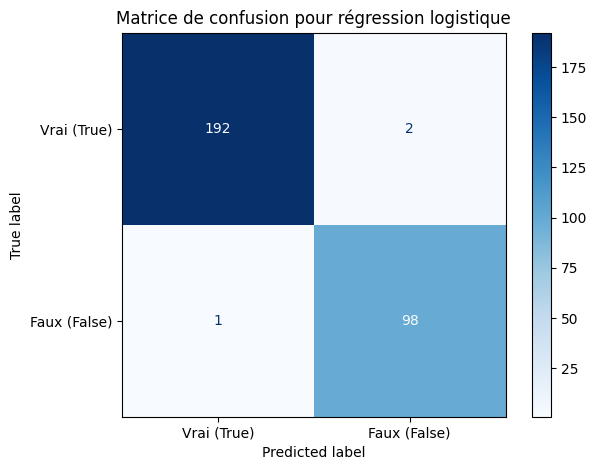


Nombre de faux billets NON détectés : 1
Nombre de vrais billets mal classés : 2


In [82]:
# Calculer la matrice de confusion à partir des vraies valeurs et des prédictions du modèle

cm_logreg = confusion_matrix(                                 # confusion_matrix() sert à comparer les vraies classes et les classes prédites
    y_test,                                                   # y_test : les vraies étiquettes du jeu de test
    y_pred,                                                   # y_pred : les prédictions faites par le modèle de régression logistique
    labels=[True, False])                                     # fixer l'ordre des classes pour lire la matrice plus facilement

# Créer un objet pour afficher la matrice de confusion sous forme de graphique

disp = ConfusionMatrixDisplay(                                # ConfusionMatrixDisplay permet d'afficher la matrice de manière visuelle
    confusion_matrix=cm_logreg,                               # utiliser la matrice de confusion calculée juste avant
    display_labels=["Vrai (True)", "Faux (False)"])           # donner des noms lisibles aux deux classes affichées

# Afficher la matrice de confusion

disp.plot(cmap="Blues")                                       # palette de couleurs bleue
plt.title("Matrice de confusion pour régression logistique")  # ajouter un titre au graphique
plt.tight_layout()                                            # ajuster automatiquement les sous-graphes
plt.show()                                                    # afficher la matrice de confusion

# Afficher le nombre de faux billets classés comme vrais
# ligne False, colonne True : faux billets prédits comme vrais

print("\nNombre de faux billets NON détectés :", cm_logreg[1][0])   

# Afficher le nombre de vrais billets classés comme faux
# ligne True, colonne False : vrais billets prédits comme faux

print("Nombre de vrais billets mal classés :", cm_logreg[0][1])

La régression logistique donne ici d’excellents résultats. Le modèle classe correctement 192 vrais billets et 98 faux billets, avec seulement 2 faux positifs et 1 faux négatif. Cette performance est particulièrement satisfaisante pour notre projet, car l’erreur la plus critique ( ne pas détecter un faux billet ) n’apparaît qu’une seule fois. On peut donc conclure que la régression logistique distingue très efficacement les billets authentiques des contrefaçons.

### 5.2.4. Métriques d'évaluation

1. **Accuracy (ou exactitude globale)** : indique la proportion de billets correctement classés. Cela permet d’évaluer rapidement la qualité globale du modèle. Cette métrique compare toutes les prédictions du modèle aux réponses correctes et calcule le taux de concordance. L’échelle est la suivante : 1,0 (ou 100 %) représente un résultat parfait, tandis qu’un résultat inférieur à 0,7 indique un résultat faible. Il est toutefois important de noter qu’une précision élevée peut apparaître même si le modèle est peu performant pour détecter les faux billets.

2. **Précision (classe Faux)** : indique la fiabilité du modèle lorsqu’il signale un faux billet. Cette métrique permet de déterminer la proportion de faux billets détectés par le modèle qui sont effectivement faux. Elle se base uniquement sur les billets identifiés comme faux par le modèle et vérifie combien d’entre eux le sont réellement. L’échelle est la suivante : 1,0 – tous les faux billets détectés par le modèle sont effectivement faux ; 0,9-0,99 – très haute précision ; 0,8-0,89 – bonne précision ; 0,7-0,79 – acceptable ; moins de 0,7 – le modèle identifie trop souvent à tort des billets authentiques comme faux.

3. **Recall / Rappel (rappel pour la classe « Faux »)** : indique la proportion de faux billets réellement détectés par le modèle. Ce paramètre permet de déterminer si le modèle passe à côté de cas dangereux. Il prend en compte tous les faux billets et vérifie combien d'entre eux ont été effectivement détectés par le modèle. L'échelle est la suivante : 1,0 – le modèle a détecté tous les faux billets ; 0,9-0,99 – très bon ; 0,8-0,89 – bon ; 0,7-0,79 – moyen ; inférieur à 0,7 – le modèle manque trop de faux billets. Ce paramètre est particulièrement important pour notre projet, car ne pas détecter un faux billet constitue l'erreur la plus critique.

4. **Score F1** : il indique l’équilibre entre la précision et le rappel. Il permet d’évaluer, à l’aide d’une seule mesure, la précision et l’exhaustivité avec lesquelles un modèle détecte les faux billets. Ce score prend en compte les deux indicateurs et est réduit si l’un des deux est faible. Échelle d’interprétation : 1,0 représente un équilibre parfait ; 0,9–0,99 un résultat très bon ; 0,8–0,89 un bon résultat ; 0,7–0,79 un résultat moyen ; et en dessous de 0,7, la qualité de la reconnaissance des faux billets est insuffisante.

In [83]:
# Importer les métriques d'évaluation nécessaires
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculer l'accuracy du modèle : métrique №1

accuracy_logreg = accuracy_score(                 # accuracy_score() calcule la proportion totale de bonnes prédictions
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred)                                       # y_pred : les classes prédites par le modèle

# Calculer la précision pour la classe Faux (False) : métrique №2

precision_logreg = precision_score(               # precision_score() mesure la proportion de billets prédits faux qui sont réellement faux
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred,                                       # y_pred : les classes prédites par le modèle
    pos_label=False)                              # pos_label=False : on considère ici les faux billets comme la classe importante

# Calculer le rappel pour la classe Faux (False) : métrique №3

recall_logreg = recall_score(                     # recall_score() mesure la capacité du modèle à retrouver les faux billets
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred,                                       # y_pred : les classes prédites par le modèle
    pos_label=False)                              # pos_label=False : on évalue ici la détection des faux billets

# Calculer le score F1 pour la classe Faux (False) : métrique №4

f1_logreg = f1_score(                             # f1_score() combine la précision et le rappel dans une seule métrique
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred,                                       # y_pred : les classes prédites par le modèle
    pos_label=False)                              # pos_label=False : on garde les faux billets comme classe prioritaire

# Afficher les résultats des métriques d'évaluation pour la régression logistique

print("Métriques d'évaluation pour la régression logistique :")   # afficher un titre pour mieux lire les résultats
print("Accuracy :", round(accuracy_logreg, 2))                    # afficher l'accuracy arrondie à 2 décimales 
print("Précision (classe Faux) :", round(precision_logreg, 2))    # afficher la précision arrondie à 2 décimales
print("Rappel (classe Faux) :", round(recall_logreg, 2))          # afficher le rappel arrondi à 2 décimales
print("F1-score (classe Faux) :", round(f1_logreg, 2))            # afficher le score F1 arrondi à 2 décimales

Métriques d'évaluation pour la régression logistique :
Accuracy : 0.99
Précision (classe Faux) : 0.98
Rappel (classe Faux) : 0.99
F1-score (classe Faux) : 0.98


Les métriques confirment les très bonnes performances de la régression logistique. L’accuracy est très élevée, et les valeurs de précision, de rappel et de F1-score pour la classe Faux montrent que le modèle détecte très efficacement les billets contrefaits. Ce résultat est particulièrement important dans notre projet, car la classe Faux est la plus sensible. Un rappel élevé signifie que le modèle laisse passer très peu de faux billets comme billets authentiques.

### 5.2.5. Courbe ROC et AUC

1. **Courbe ROC ( Receiver Operating Characteristic )** : elle permet d’observer l’évolution des performances du modèle en fonction des différents seuils de décision. Elle illustre l’équilibre entre la capacité à identifier la classe recherchée et le nombre de faux positifs. Autrement dit, la courbe ROC nous aide à comprendre l’impact d’une plus grande rigueur ou d’une plus grande « sensibilité » du modèle. Ceci est particulièrement utile pour notre projet, car nous pouvons ainsi évaluer l’évolution du compromis entre la détection des faux billets et le risque de classer à tort des billets authentiques comme contrefaits.

2. **AUC ( Area Under the Curve )** : elle permet de réduire la courbe ROC à une seule valeur et d'évaluer rapidement l'ensemble du modèle. Elle indique dans quelle mesure le modèle, pris dans son ensemble, distingue deux classes : les billets authentiques et les faux. Autrement dit, plus l'AUC est proche de 1, meilleure est la séparation des classes. Une AUC de 0,5 signifie que le modèle fonctionne approximativement comme une réponse aléatoire.

Ordre des classes du modèle : [False  True]
AUC pour la classe Faux : 1.0


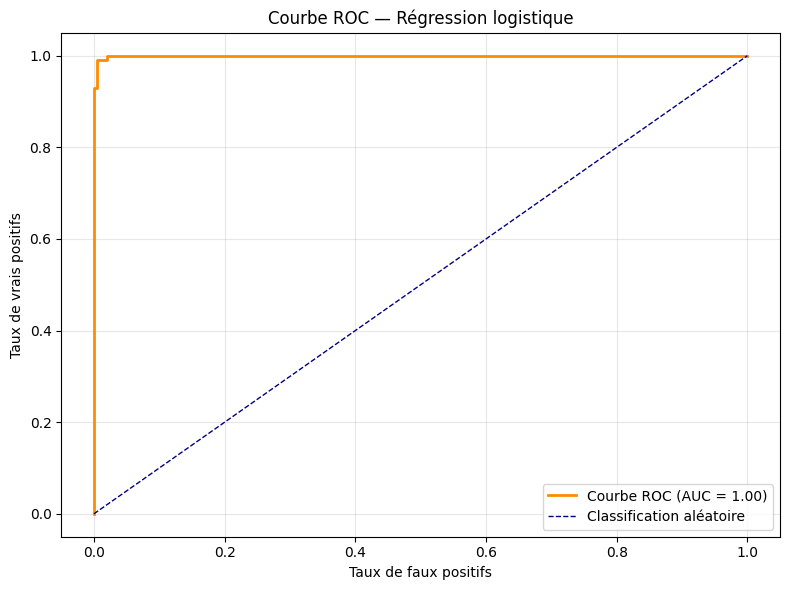

In [84]:
# Importer les fonctions nécessaires pour la courbe ROC et l'AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Obtenir les probabilités prédites par le modèle pour chaque classe
# predict_proba() retourne un tableau de probabilités pour chaque classe 
# (True et False) pour chaque observation du test
y_proba = logreg.predict_proba(X_test_scaled)

# Afficher l'ordre des classes appris par le modèle
# C'est nécessaire car les colonnes de predict_proba() sont ordonnées 
# selon l'ordre stocké dans logreg.classes_. Sinon, nous pourrions 
# par erreur prendre la probabilité de la mauvaise classe.
print("Ordre des classes du modèle :", logreg.classes_)           

# Trouver la position de la classe Faux (False) dans le modèle
# Autrement dit, le code ne fait aucune supposition, mais vérifie d'abord l'ordre
index_false = list(logreg.classes_).index(False)

# Extraire la probabilité prédite pour la classe Faux (False)
# C'est important car dans notre projet, les faux billets sont la catégorie prioritaire
y_proba_false = y_proba[:, index_false]

# Convertir la variable réelle en format numérique pour la courbe ROC
# Car la fonction ROC fonctionne avec des nombres (format binaire 0/1) et non avec des booléens (True/False)
# 1 = faux billet ; 0 = vrai billet
y_test_false = (y_test == False).astype(int)

# Calculer les coordonnées de la courbe ROC
# Cette fonction parcourt différents seuils de décision et calcule :
# fpr = taux de faux positifs
# tpr = proportion de faux billets correctement détectés
# thresholds = les seuils eux-mêmes
# À partir de ces points, une courbe ROC est ensuite construite
fpr, tpr, thresholds = roc_curve(
    y_test_false,        # vraies classes converties en 0 et 1
    y_proba_false)       # probabilités prédites pour la classe Faux

# Calculer l'aire sous la courbe ROC (AUC) pour évaluer la performance globale du modèle
auc_logreg = roc_auc_score(
    y_test_false,        # vraies classes converties en 0 et 1
    y_proba_false)       # probabilités prédites pour la classe Faux

# Afficher la valeur de l'AUC
# auc_logreg est la valeur AUC déjà calculée pour la régression logistique
print("AUC pour la classe Faux :", round(auc_logreg, 2))

# Créer une figure pour afficher la courbe ROC
plt.figure(figsize=(8, 6))

# Tracer la courbe ROC du modèle
plt.plot(
    fpr,                                           # axe X : taux de faux positifs
    tpr,                                           # axe Y : taux de vrais positifs
    color="darkorange",                            # couleur de la courbe
    linewidth=2,                                   # épaisseur de la ligne
    label=f"Courbe ROC (AUC = {auc_logreg:.2f})")  # légende avec la valeur AUC

# Tracer la ligne de référence d'un modèle aléatoire
plt.plot(
    [0, 1],                                        # axe X de la diagonale
    [0, 1],                                        # axe Y de la diagonale
    color="navy",                                  # couleur de la ligne
    linewidth=1,                                   # épaisseur de la ligne
    linestyle="--",                                # style en pointillés
    label="Classification aléatoire")              # légende

plt.xlabel("Taux de faux positifs")                # étiquette de l'axe X pour indiquer qu'il s'agit du taux de faux positifs
plt.ylabel("Taux de vrais positifs")               # étiquette de l'axe Y pour indiquer qu'il s'agit du taux de vrais positifs
plt.title("Courbe ROC — Régression logistique")    # titre du graphique pour indiquer qu'il s'agit de la courbe ROC pour la régression logistique
plt.legend(loc="lower right")                      # Afficher la légende
plt.grid(True, alpha=0.3)                          # Ajouter une grille légère
plt.tight_layout()                                 # Ajuster automatiquement l'affichage
plt.show()                                         # Afficher le graphique

Sur le graphique ROC, la courbe atteint presque immédiatement la valeur 1 sur l'axe des valeurs positives (pourcentage de faux positifs) et passe très près du coin supérieur gauche. Cela signifie que le modèle est très performant pour détecter les faux billets : même avec un taux de faux positifs quasi nul, il détecte la quasi-totalité des contrefaçons. Pour votre problème, il s'agit d'un résultat très probant, car la détection des faux billets est cruciale.

Une AUC de 1,00 signifie que le modèle distingue presque parfaitement les deux classes de probabilité : billets authentiques et faux. Autrement dit, face à un faux billet et un billet authentique choisis au hasard, le modèle attribuera presque toujours une probabilité plus élevée à la classe « Faux » pour le faux billet. Ceci confirme que la régression logistique est parfaitement adaptée à votre projet.

**Résultat** : Le modèle distingue presque parfaitement les vrais billets des faux, et la valeur AUC de 1,00 démontre une très grande capacité de discrimination entre les classes. La régression logistique s’avère donc un modèle très performant pour cette tâche.

## 5.3. KNN

KNN = K-Nearest Neighbors (K plus proches voisins). **Principe** : pour classifier un nouvel objet, l’algorithme trouve les k objets les plus proches de lui dans l’ensemble d’apprentissage et lui attribue la classe majoritaire parmi ces voisins. 

Navigation à travers les étapes de mise en œuvre de l’algorithme :

1. Nous commençons par choisir le nombre optimal de voisins (k) à l'aide de la validation croisée sur les données d'entraînement. Cette étape est propre à KNN : le choix de k influence directement la qualité des prédictions.

2. Nous entraînons ensuite le modèle KNN avec le meilleur k trouvé sur les données d'entraînement standardisées. Le modèle mémorise toutes les observations et les utilise pour classer les nouveaux billets.

3. Nous appliquons le modèle entraîné aux données de test afin d'obtenir les prédictions pour chaque billet.

4. Nous construisons la matrice de confusion pour visualiser les erreurs du modèle et identifier les faux billets non détectés — l'erreur la plus critique dans notre projet.

5. Nous calculons les métriques d'évaluation détaillées : précision, rappel, F1-score et exactitude globale. Ces métriques permettent de quantifier la performance du modèle de manière complète.

6. Nous traçons la courbe ROC et calculons l'aire sous la courbe (AUC) afin d'évaluer la capacité du modèle à distinguer les billets vrais des faux, indépendamment du seuil de décision.


### 5.3.1. Choix du nombre de voisins

Pour notre jeu de données, le k retenu entre 1 et 20 est optimal car c’est celui qui donne la meilleure accuracy moyenne en validation croisée sur les données d’entraînement. Un k plus petit serait plus sensible au bruit, tandis qu’un k plus grand lisserait trop les différences entre vrais et faux billets.

k= 1 : accuracy = 0.985
k= 2 : accuracy = 0.981
k= 3 : accuracy = 0.990
k= 4 : accuracy = 0.989
k= 5 : accuracy = 0.991
k= 6 : accuracy = 0.991
k= 7 : accuracy = 0.991
k= 8 : accuracy = 0.992
k= 9 : accuracy = 0.991
k=10 : accuracy = 0.991
k=11 : accuracy = 0.990
k=12 : accuracy = 0.991
k=13 : accuracy = 0.991
k=14 : accuracy = 0.991
k=15 : accuracy = 0.991
k=16 : accuracy = 0.991
k=17 : accuracy = 0.991
k=18 : accuracy = 0.991
k=19 : accuracy = 0.990
k=20 : accuracy = 0.990

Meilleur k : 8


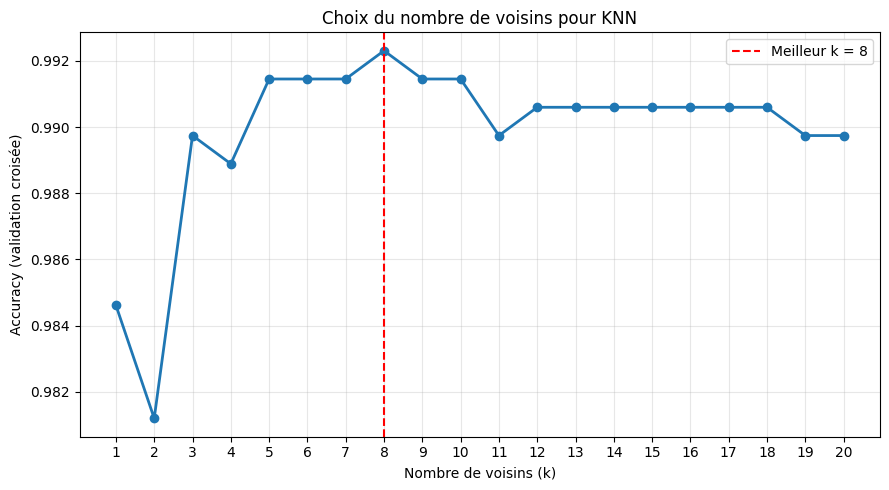

In [85]:
# Importer le modèle KNN et la validation croisée
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Créer une liste vide pour stocker les scores pour chaque k
accuracy_scores = []

# Choix du nombre optimal de voisins par validation croisée - c'est une méthode 
# pour tester un modèle non pas sur une seule division aléatoire, mais sur plusieurs
# L'estimation est plus fiable qu'avec une vérification unique et
# le résultat est moins dépendant d'un partitionnement aléatoire des données

# Le modèle est entraîné et évalué cinq fois : à chaque fois, 4 parties 
# sont utilisées pour l’entraînement et 1 partie pour la validation. 
# La partie de validation change ensuite afin que chacune des 5 parties joue 1 fois 
# le rôle d’ensemble de validation. Au final, on obtient 5 valeurs d’accuracy

# cv=5 est un bon compromis pratique. Avec 2 ou 3, l’évaluation serait plus grossière ; 
# avec 10 ou plus, le temps de calcul augmente, et le gain en qualité de l’estimation 
# est souvent faible par rapport à cv=5

for k in range(1, 21):                                         # tester k de 1 à 20
    knn_temp = KNeighborsClassifier(n_neighbors=k)             # créer un modèle KNN avec k voisins
    scores = cross_val_score(                                  # évaluer le modèle par validation croisée
        knn_temp,                                              # modèle à évaluer
        X_train_scaled,                                        # données d'entraînement standardisées
        y_train,                                               # vraies classes
        cv=5,                                                  # diviser les données en 5 parties, 5 est une valeur très courante dans scikit-learn
        scoring='accuracy')                                    # mesurer l'accuracy
    accuracy_scores.append(scores.mean())                      # enregistrer le score moyen pour ce k
    print(f"k={k:2d} : accuracy = {scores.mean():.3f}")        # afficher le résultat pour ce k

# Trouver le meilleur k : celui avec le score le plus élevé

# La liste `accuracy_scores` contient déjà les valeurs de précision moyennes pour chaque valeur de k
# `max(accuracy_scores)` trouve le score le plus élevé dans cette liste
# `accuracy_scores.index(...)` trouve la position de ce meilleur score dans la liste
# Cette position est l'index, mais en Python, l'indexation commence à 0
# Nos valeurs de k commencent à 1, donc on ajoute 1 pour obtenir le meilleur k correspondant à ce score

best_k = accuracy_scores.index(max(accuracy_scores)) + 1       # +1 car l'index commence à 0
print(f"\nMeilleur k : {best_k}")                              # afficher le meilleur k trouvé

# Creer le graphique des scores en fonction de k

plt.figure(figsize=(9, 5))                                     # définir la taille du graphique
plt.plot(                                                      # tracer une courbe
    range(1, 21),                                              # axe X : valeurs de k de 1 à 20
    accuracy_scores,                                           # axe Y : accuracy pour chaque k
    marker='o',                                                # marqueur pour chaque point
    linewidth=2)                                               # épaisseur de la ligne
plt.axvline(                                                   # ajouter une ligne verticale pour indiquer le meilleur k
    x=best_k,                                                  # ligne verticale au meilleur k
    color='red',                                               # couleur rouge
    linestyle='--',                                            # style en pointillés
    label=f'Meilleur k = {best_k}')                            # légende avec la valeur du meilleur k
plt.xlabel('Nombre de voisins (k)')                            # étiquette de l'axe X
plt.ylabel('Accuracy (validation croisée)')                    # étiquette de l'axe Y
plt.title('Choix du nombre de voisins pour KNN')               # titre du graphique
plt.xticks(range(1, 21))                                       # marques sur l'axe X : 1, 2, ..., 20
plt.legend()                                                   # afficher la légende
plt.grid(True, alpha=0.3)                                      # grille légère
plt.tight_layout()                                             # ajuster l'affichage
plt.show()                                                     # afficher le graphique

Le graphique montre que le modèle KNN devient rapidement performant dès les premières valeurs de k, puis les résultats restent globalement très stables. Le meilleur score est obtenu pour k = 8, ce qui signifie que ce nombre de voisins semble être le plus adapté pour bien distinguer les vrais billets des faux dans notre jeu de données. Même si d’autres valeurs proches donnent des résultats similaires, k = 8 reste le meilleur choix selon la validation croisée.

### 5.3.2. Entraînement du modèle

Ce bloc consiste à entraîner le modèle KNN sur les données d’entraînement standardisées en utilisant le meilleur nombre de voisins trouvé précédemment. À cette étape, le modèle mémorise les observations de l’ensemble d’apprentissage afin de pouvoir ensuite classer les nouveaux billets selon leurs voisins les plus proches.

In [86]:
# Créer le modèle KNN avec le meilleur nombre de voisins trouvé précédemment

knn = KNeighborsClassifier(                # créer une variable appelée knn qui contient le modèle
    n_neighbors=best_k)                    # utiliser le meilleur nombre de voisins trouvé par validation croisée

# Lancer l'entraînement du modèle sur les données d'entraînement déjà standardisées
# Pour KNN, cette étape consiste surtout à mémoriser les observations d'entraînement

knn.fit(                                   # fit() prépare le modèle KNN à partir des données d'entraînement
    X_train_scaled,                        # X_train_scaled : les données d'entrée pour l'entraînement (caractéristiques standardisées)
    y_train)                               # y_train : les étiquettes cibles pour l'entraînement (True/False)

print(f"Le modèle KNN a été entraîné avec succès avec k = {best_k}")   # afficher un message de succès

Le modèle KNN a été entraîné avec succès avec k = 8


### 5.3.3. Prédiction sur les données de test

Dans ce bloc, nous utilisons le modèle KNN déjà entraîné pour prédire la classe des billets de l’ensemble de test. Chaque billet est classé selon la classe majoritaire parmi ses voisins les plus proches dans les données d’entraînement.

In [87]:
# Utiliser le modèle KNN déjà entraîné pour faire des prédictions

y_pred_knn = knn.predict(        # méthode predict() est utilisée pour faire des prédictions à partir du modèle entraîné
    X_test_scaled)               # X_test_scaled : les données d'entrée pour les prédictions (caractéristiques standardisées du test)

print("Prédictions du modèle KNN sur les données de test :")    # afficher un titre pour rendre le résultat plus lisible
print(y_pred_knn[:20])                                          # afficher les 20 premières prédictions du modèle
print("Nombre total de prédictions :", len(y_pred_knn))         # afficher le nombre total de prédictions réalisées

Prédictions du modèle KNN sur les données de test :
[ True  True False False  True  True  True False False  True  True  True
  True False  True  True False  True  True  True]
Nombre total de prédictions : 293


### 5.3.4. Matrice de confusion

La matrice de confusion compare les vraies étiquettes (y_test) avec les prédictions du modèle KNN (y_pred_knn). Elle permet de visualiser les bonnes prédictions et les erreurs du modèle. Dans notre projet, elle est particulièrement utile pour repérer les faux billets non détectés, c’est-à-dire les faux billets classés à tort comme vrais.

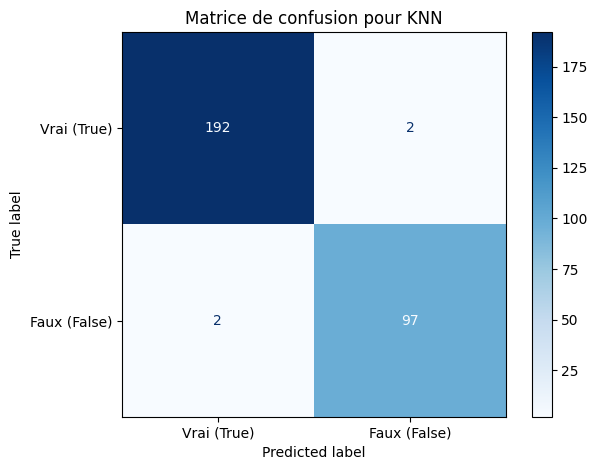


Nombre de faux billets NON détectés : 2
Nombre de vrais billets mal classés : 2


In [88]:
# Calculer la matrice de confusion à partir des vraies valeurs et des prédictions du modèle KNN

cm_knn = confusion_matrix(                                    # confusion_matrix() sert à comparer les vraies classes et les classes prédites
    y_test,                                                   # y_test : les vraies étiquettes du jeu de test
    y_pred_knn,                                               # y_pred_knn : les prédictions faites par le modèle KNN
    labels=[True, False])                                     # fixer l'ordre des classes pour lire la matrice plus facilement

# Créer un objet pour afficher la matrice de confusion sous forme de graphique

disp = ConfusionMatrixDisplay(                                # ConfusionMatrixDisplay permet d'afficher la matrice de manière visuelle
    confusion_matrix=cm_knn,                                  # utiliser la matrice de confusion calculée juste avant
    display_labels=["Vrai (True)", "Faux (False)"])           # donner des noms lisibles aux deux classes affichées

# Afficher la matrice de confusion

disp.plot(cmap="Blues")                                       # palette de couleurs bleue
plt.title("Matrice de confusion pour KNN")                    # ajouter un titre au graphique
plt.tight_layout()                                            # ajuster automatiquement les sous-graphiques
plt.show()                                                    # afficher la matrice de confusion

# Afficher le nombre de faux billets classés comme vrais
# ligne False, colonne True : faux billets prédits comme vrais

print("\nNombre de faux billets NON détectés :", cm_knn[1][0])

# Afficher le nombre de vrais billets classés comme faux
# ligne True, colonne False : vrais billets prédits comme faux

print("Nombre de vrais billets mal classés :", cm_knn[0][1])

La matrice de confusion montre que le modèle KNN classe globalement bien les billets. L’élément le plus important à surveiller reste le nombre de faux billets non détectés, car c’est l’erreur la plus critique dans notre projet.

### 5.3.5. Métriques d'évaluation

Dans ce bloc, nous calculons les principales métriques d’évaluation du modèle KNN : l’accuracy, la précision, le rappel et le score F1. Ces indicateurs permettent de mesurer plus précisément la qualité du modèle, en particulier sa capacité à détecter les faux billets.

In [89]:
# Calculer les métriques d'évaluation du modèle KNN

# Calculer l'accuracy du modèle : métrique №1

accuracy_knn = accuracy_score(                    # accuracy_score() calcule la proportion totale de bonnes prédictions
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred_knn)                                   # y_pred_knn : les classes prédites par le modèle KNN

# Calculer la précision pour la classe Faux (False) : métrique №2

precision_knn = precision_score(                  # precision_score() mesure la proportion de billets prédits faux qui sont réellement faux
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred_knn,                                   # y_pred_knn : les classes prédites par le modèle KNN
    pos_label=False)                              # pos_label=False : on considère ici les faux billets comme la classe importante

# Calculer le rappel pour la classe Faux (False) : métrique №3

recall_knn = recall_score(                        # recall_score() mesure la capacité du modèle à retrouver les faux billets
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred_knn,                                   # y_pred_knn : les classes prédites par le modèle KNN
    pos_label=False)                              # pos_label=False : on évalue ici la détection des faux billets

# Calculer le score F1 pour la classe Faux (False) : métrique №4

f1_knn = f1_score(                                # f1_score() combine la précision et le rappel dans une seule métrique
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred_knn,                                   # y_pred_knn : les classes prédites par le modèle KNN
    pos_label=False)                              # pos_label=False : on garde les faux billets comme classe prioritaire

# Afficher les résultats des métriques d'évaluation pour le modèle KNN
print("Métriques d'évaluation pour le modèle KNN :")         # afficher un titre pour mieux lire les résultats
print("Accuracy :", round(accuracy_knn, 2))                  # afficher l'accuracy arrondie à 2 décimales
print("Précision (classe Faux) :", round(precision_knn, 2))  # afficher la précision arrondie à 2 décimales
print("Rappel (classe Faux) :", round(recall_knn, 2))        # afficher le rappel arrondi à 2 décimales
print("F1-score (classe Faux) :", round(f1_knn, 2))          # afficher le score F1 arrondi à 2 décimales

Métriques d'évaluation pour le modèle KNN :
Accuracy : 0.99
Précision (classe Faux) : 0.98
Rappel (classe Faux) : 0.98
F1-score (classe Faux) : 0.98


Les métriques d’évaluation montrent que le modèle KNN obtient d’excellents résultats. L’accuracy est très élevée, et les valeurs de précision, de rappel et de F1-score pour la classe Faux indiquent que le modèle détecte très bien les billets contrefaits. Cela signifie que le modèle est globalement fiable et qu’il commet très peu d’erreurs sur notre jeu de test.

### 5.3.6. Courbe ROC et AUC

Dans ce bloc, nous traçons la courbe ROC et calculons l’aire sous la courbe (AUC) pour le modèle KNN. Cela permet d’évaluer la capacité du modèle à distinguer les vrais billets des faux selon différents seuils de décision, et pas uniquement avec les classes prédites finales.

Ordre des classes du modèle KNN : [False  True]
AUC pour la classe Faux : 1.0


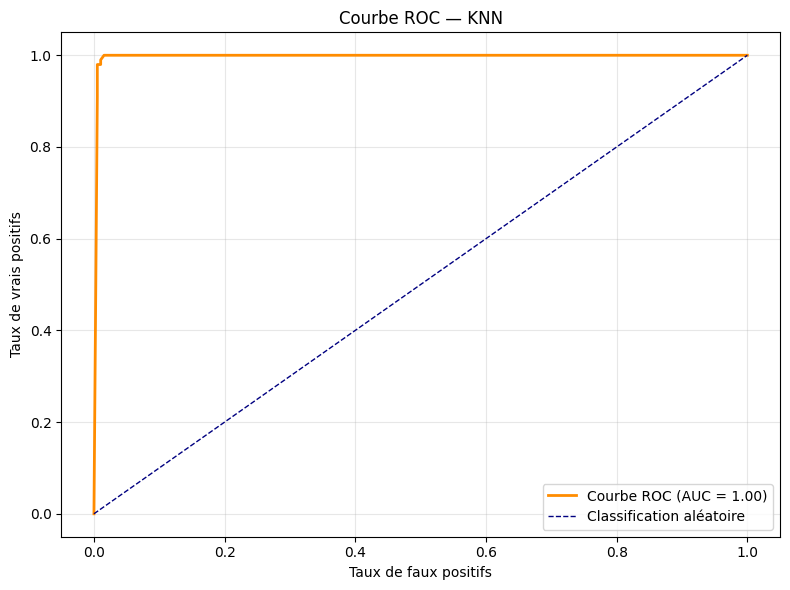

In [90]:
# Obtenir les probabilités prédites par le modèle KNN pour chaque classe
# predict_proba() retourne un tableau de probabilités pour chaque classe
# (True et False) pour chaque observation du test

y_proba_knn = knn.predict_proba(X_test_scaled)

# Afficher l'ordre des classes appris par le modèle
# C'est nécessaire car les colonnes de predict_proba() sont ordonnées
# selon l'ordre stocké dans knn.classes_

print("Ordre des classes du modèle KNN :", knn.classes_)

# Trouver la position de la classe Faux (False) dans le modèle

index_false_knn = list(knn.classes_).index(False)

# Extraire la probabilité prédite pour la classe Faux (False)
# C'est important car dans notre projet, les faux billets sont la catégorie prioritaire

y_proba_false_knn = y_proba_knn[:, index_false_knn]

# Convertir la variable réelle en format numérique pour la courbe ROC
# 1 = faux billet ; 0 = vrai billet

y_test_false_knn = (y_test == False).astype(int)

# Calculer les coordonnées de la courbe ROC
# fpr = taux de faux positifs
# tpr = proportion de faux billets correctement détectés
# thresholds = les seuils de décision

fpr_knn, tpr_knn, thresholds_knn = roc_curve(
    y_test_false_knn,          # vraies classes converties en 0 et 1
    y_proba_false_knn)         # probabilités prédites pour la classe Faux

# Calculer l'aire sous la courbe ROC (AUC) pour évaluer la performance globale du modèle

auc_knn = roc_auc_score(
    y_test_false_knn,          # vraies classes converties en 0 et 1
    y_proba_false_knn)         # probabilités prédites pour la classe Faux

# Afficher la valeur de l'AUC

print("AUC pour la classe Faux :", round(auc_knn, 2))

# Créer une figure pour afficher la courbe ROC

plt.figure(figsize=(8, 6))

# Tracer la courbe ROC du modèle KNN

plt.plot(
    fpr_knn,                                   # axe X : taux de faux positifs
    tpr_knn,                                   # axe Y : taux de vrais positifs
    color="darkorange",                        # couleur de la courbe
    linewidth=2,                               # épaisseur de la ligne
    label=f"Courbe ROC (AUC = {auc_knn:.2f})") # légende avec la valeur AUC

# Tracer la ligne de référence d'un modèle aléatoire

plt.plot(
    [0, 1],                                    # axe X de la diagonale
    [0, 1],                                    # axe Y de la diagonale
    color="navy",                              # couleur de la ligne
    linewidth=1,                               # épaisseur de la ligne
    linestyle="--",                            # style en pointillés
    label="Classification aléatoire")          # légende

plt.xlabel("Taux de faux positifs")            # étiquette de l'axe X
plt.ylabel("Taux de vrais positifs")           # étiquette de l'axe Y
plt.title("Courbe ROC — KNN")                  # titre du graphique
plt.legend(loc="lower right")                  # afficher la légende
plt.grid(True, alpha=0.3)                      # ajouter une grille légère
plt.tight_layout()                             # ajuster automatiquement l'affichage
plt.show()                                     # afficher le graphique

La courbe ROC montre que le modèle KNN reconnaît très bien les faux billets et les vrais billets. La courbe est très proche du coin supérieur gauche, ce qui veut dire que le modèle fait très peu d’erreurs. La valeur AUC de 1,00 confirme que le modèle sépare presque parfaitement les deux classes.

## 5.4. Random forest

Le Random Forest est un modèle d’ensemble basé sur plusieurs arbres de décision. Chaque arbre apprend des règles de séparation à partir des données, puis la prédiction finale est obtenue par vote majoritaire. Ce modèle est souvent très performant pour la classification et permet aussi d’identifier les variables les plus importantes.

1. Nous entraînons le modèle Random Forest sur les données d’entraînement.

2. Nous utilisons ensuite le modèle entraîné pour prédire la classe des billets de l’ensemble de test.

3. Nous construisons la matrice de confusion pour visualiser les bonnes prédictions et les erreurs.

4. Nous calculons les métriques d’évaluation principales : accuracy, précision, rappel et F1-score.

5. Nous traçons la courbe ROC et calculons l’AUC pour évaluer la capacité du modèle à distinguer les vrais billets des faux.

6. Enfin, nous analysons l’importance des variables afin de voir quels indicateurs influencent le plus les décisions du modèle.

### 5.4.1. Entraînement du modèle

Contrairement à certains modèles comme KNN ou la régression logistique, Random Forest n’a pas besoin de données standardisées pour fonctionner correctement. Dans ce bloc, nous entraînons donc le modèle sur les données d’entraînement d’origine afin qu’il apprenne à distinguer les vrais billets des faux à partir des six caractéristiques.

In [91]:
# Importer le modèle Random Forest depuis la bibliothèque sklearn
from sklearn.ensemble import RandomForestClassifier

# Créer le modèle Random Forest
# n_estimators=100 signifie que la forêt contient 100 arbres de décision
# random_state=39 permet d'obtenir le même résultat à chaque exécution

rf = RandomForestClassifier(                 # créer une variable appelée rf qui contient le modèle
    n_estimators=100,                        # nombre d'arbres dans la forêt
    random_state=39)                         # fixer une valeur aléatoire constante pour la reproductibilité

# Lancer l'entraînement du modèle sur les données d'entraînement non standardisées
# Random Forest fonctionne bien directement sur les variables d'origine

rf.fit(                                      # fit() entraîne le modèle Random Forest
    X_train,                                 # X_train : les données d'entrée pour l'entraînement
    y_train)                                 # y_train : les étiquettes cibles pour l'entraînement (True/False)

print("Le modèle Random Forest a été entraîné avec succès")   # afficher un message de succès

Le modèle Random Forest a été entraîné avec succès


### 5.4.2. Prédiction sur les données de test

Dans ce bloc, nous utilisons le modèle Random Forest déjà entraîné pour prédire la classe des billets de l’ensemble de test. La prédiction finale est obtenue à partir du vote majoritaire des différents arbres de décision de la forêt.

In [92]:
# Utiliser le modèle Random Forest déjà entraîné pour faire des prédictions

y_pred_rf = rf.predict(                     # méthode predict() est utilisée pour faire des prédictions à partir du modèle entraîné
    X_test)                                 # X_test : les données d'entrée pour les prédictions du test

print("Prédictions du modèle Random Forest sur les données de test :")   # afficher un titre pour rendre le résultat plus lisible
print(y_pred_rf[:20])                                                    # afficher les 20 premières prédictions du modèle
print("Nombre total de prédictions :", len(y_pred_rf))                   # afficher le nombre total de prédictions réalisées

Prédictions du modèle Random Forest sur les données de test :
[ True  True False False  True  True  True False False  True  True  True
  True False  True  True False  True  True  True]
Nombre total de prédictions : 293


### 5.4.3. Matrice de confusion

La matrice de confusion compare les vraies étiquettes (y_test) avec les prédictions du modèle Random Forest (y_pred_rf). Elle permet de visualiser les bonnes prédictions et les erreurs du modèle. Dans notre projet, elle est particulièrement utile pour repérer les faux billets non détectés, c’est-à-dire les faux billets classés à tort comme vrais.

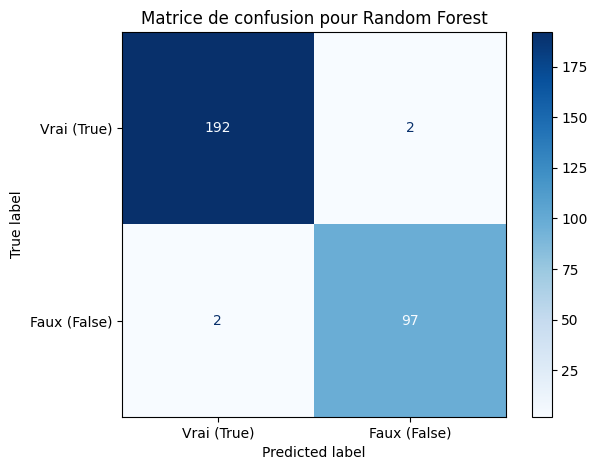


Nombre de faux billets NON détectés : 2
Nombre de vrais billets mal classés : 2


In [93]:
# Calculer la matrice de confusion à partir des vraies valeurs et des prédictions du modèle Random Forest

cm_rf = confusion_matrix(                                      # confusion_matrix() sert à comparer les vraies classes et les classes prédites
    y_test,                                                    # y_test : les vraies étiquettes du jeu de test
    y_pred_rf,                                                 # y_pred_rf : les prédictions faites par le modèle Random Forest
    labels=[True, False])                                      # fixer l'ordre des classes pour lire la matrice plus facilement

# Créer un objet pour afficher la matrice de confusion sous forme de graphique

disp = ConfusionMatrixDisplay(                                 # ConfusionMatrixDisplay permet d'afficher la matrice de manière visuelle
    confusion_matrix=cm_rf,                                    # utiliser la matrice de confusion calculée juste avant
    display_labels=["Vrai (True)", "Faux (False)"])            # donner des noms lisibles aux deux classes affichées

# Afficher la matrice de confusion

disp.plot(cmap="Blues")                                        # palette de couleurs bleue
plt.title("Matrice de confusion pour Random Forest")           # ajouter un titre au graphique
plt.tight_layout()                                             # ajuster automatiquement les sous-graphiques
plt.show()                                                     # afficher la matrice de confusion

# Afficher le nombre de faux billets classés comme vrais
# ligne False, colonne True : faux billets prédits comme vrais

print("\nNombre de faux billets NON détectés :", cm_rf[1][0])

# Afficher le nombre de vrais billets classés comme faux
# ligne True, colonne False : vrais billets prédits comme faux

print("Nombre de vrais billets mal classés :", cm_rf[0][1])

La matrice de confusion montre que le modèle Random Forest classe très bien les billets. Il identifie correctement 192 vrais billets et 97 faux billets, avec seulement 2 faux billets non détectés et 2 vrais billets mal classés. Cela veut dire que le modèle est globalement très fiable et qu’il fait très peu d’erreurs sur les données de test.

### 5.4.4. Métriques d'évaluation

Dans ce bloc, nous calculons les principales métriques d’évaluation du modèle Random Forest : l’accuracy, la précision, le rappel et le score F1. Ces indicateurs permettent de mesurer plus précisément la qualité du modèle, en particulier sa capacité à détecter les faux billets.

In [94]:
# Calculer les métriques d'évaluation du modèle Random Forest

# Calculer l'accuracy du modèle : métrique №1

accuracy_rf = accuracy_score(                     # accuracy_score() calcule la proportion totale de bonnes prédictions
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred_rf)                                    # y_pred_rf : les classes prédites par le modèle Random Forest

# Calculer la précision pour la classe Faux (False) : métrique №2

precision_rf = precision_score(                   # precision_score() mesure la proportion de billets prédits faux qui sont réellement faux
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred_rf,                                    # y_pred_rf : les classes prédites par le modèle Random Forest
    pos_label=False)                              # pos_label=False : on considère ici les faux billets comme la classe importante

# Calculer le rappel pour la classe Faux (False) : métrique №3

recall_rf = recall_score(                         # recall_score() mesure la capacité du modèle à retrouver les faux billets
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred_rf,                                    # y_pred_rf : les classes prédites par le modèle Random Forest
    pos_label=False)                              # pos_label=False : on évalue ici la détection des faux billets

# Calculer le score F1 pour la classe Faux (False) : métrique №4

f1_rf = f1_score(                                 # f1_score() combine la précision et le rappel dans une seule métrique
    y_test,                                       # y_test : les vraies classes du jeu de test
    y_pred_rf,                                    # y_pred_rf : les classes prédites par le modèle Random Forest
    pos_label=False)                              # pos_label=False : on garde les faux billets comme classe prioritaire

# Afficher les résultats des métriques d'évaluation pour le modèle Random Forest

print("Métriques d'évaluation pour le modèle Random Forest :")   # afficher un titre pour mieux lire les résultats
print("Accuracy :", round(accuracy_rf, 2))                       # afficher l'accuracy arrondie à 2 décimales
print("Précision (classe Faux) :", round(precision_rf, 2))       # afficher la précision arrondie à 2 décimales
print("Rappel (classe Faux) :", round(recall_rf, 2))             # afficher le rappel arrondi à 2 décimales
print("F1-score (classe Faux) :", round(f1_rf, 2))               # afficher le score F1 arrondi à 2 décimales

Métriques d'évaluation pour le modèle Random Forest :
Accuracy : 0.99
Précision (classe Faux) : 0.98
Rappel (classe Faux) : 0.98
F1-score (classe Faux) : 0.98


Les métriques d’évaluation montrent que le modèle Random Forest obtient d’excellents résultats. L’accuracy est très élevée, et les valeurs de précision, de rappel et de F1-score pour la classe Faux indiquent que le modèle détecte très bien les billets contrefaits. Cela signifie que le modèle est globalement fiable et qu’il commet très peu d’erreurs sur notre jeu de test.

### 5.4.5. Courbe ROC et AUC

Dans ce bloc, nous traçons la courbe ROC et calculons l’aire sous la courbe (AUC) pour le modèle Random Forest. Cela permet d’évaluer la capacité du modèle à distinguer les vrais billets des faux selon différents seuils de décision, et pas uniquement avec les classes prédites finales.

Ordre des classes du modèle Random Forest : [False  True]
AUC pour la classe Faux : 1.0


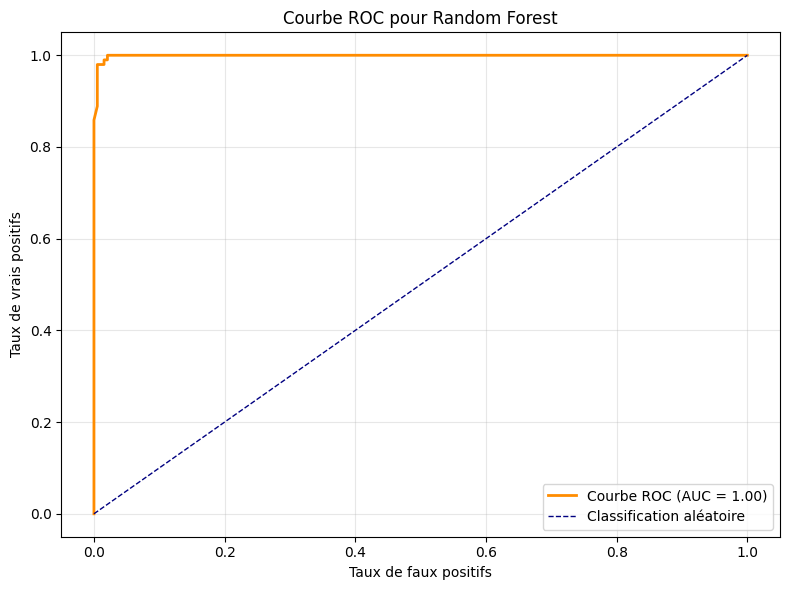

In [95]:
# Obtenir les probabilités prédites par le modèle Random Forest pour chaque classe
# predict_proba() retourne un tableau de probabilités pour chaque classe
# (True et False) pour chaque observation du test

y_proba_rf = rf.predict_proba(X_test)

# Afficher l'ordre des classes appris par le modèle
# C'est nécessaire car les colonnes de predict_proba() sont ordonnées
# selon l'ordre stocké dans rf.classes_

print("Ordre des classes du modèle Random Forest :", rf.classes_)

# Trouver la position de la classe Faux (False) dans le modèle

index_false_rf = list(rf.classes_).index(False)

# Extraire la probabilité prédite pour la classe Faux (False)
# C'est important car dans notre projet, les faux billets sont la catégorie prioritaire

y_proba_false_rf = y_proba_rf[:, index_false_rf]

# Convertir la variable réelle en format numérique pour la courbe ROC
# 1 = faux billet ; 0 = vrai billet

y_test_false_rf = (y_test == False).astype(int)

# Calculer les coordonnées de la courbe ROC
# fpr = taux de faux positifs
# tpr = proportion de faux billets correctement détectés
# thresholds = les seuils de décision

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test_false_rf,          # vraies classes converties en 0 et 1
    y_proba_false_rf)         # probabilités prédites pour la classe Faux

# Calculer l'aire sous la courbe ROC (AUC) pour évaluer la performance globale du modèle

auc_rf = roc_auc_score(
    y_test_false_rf,          # vraies classes converties en 0 et 1
    y_proba_false_rf)         # probabilités prédites pour la classe Faux

# Afficher la valeur de l'AUC

print("AUC pour la classe Faux :", round(auc_rf, 2))

# Créer une figure pour afficher la courbe ROC

plt.figure(figsize=(8, 6))

# Tracer la courbe ROC du modèle Random Forest

plt.plot(
    fpr_rf,                                  # axe X : taux de faux positifs
    tpr_rf,                                  # axe Y : taux de vrais positifs
    color="darkorange",                      # couleur de la courbe
    linewidth=2,                             # épaisseur de la ligne
    label=f"Courbe ROC (AUC = {auc_rf:.2f})")# légende avec la valeur AUC

# Tracer la ligne de référence d'un modèle aléatoire

plt.plot(
    [0, 1],                                  # axe X de la diagonale
    [0, 1],                                  # axe Y de la diagonale
    color="navy",                            # couleur de la ligne
    linewidth=1,                             # épaisseur de la ligne
    linestyle="--",                          # style en pointillés
    label="Classification aléatoire")        # légende

plt.xlabel("Taux de faux positifs")          # étiquette de l'axe X
plt.ylabel("Taux de vrais positifs")         # étiquette de l'axe Y
plt.title("Courbe ROC pour Random Forest")      # titre du graphique
plt.legend(loc="lower right")                # afficher la légende
plt.grid(True, alpha=0.3)                    # ajouter une grille légère
plt.tight_layout()                           # ajuster automatiquement l'affichage
plt.show()                                   # afficher le graphique

La courbe ROC montre que le modèle Random Forest sépare presque parfaitement les vrais billets des faux billets. La courbe est très proche du coin supérieur gauche, ce qui veut dire que le modèle détecte très bien les faux billets tout en faisant très peu d’erreurs. La valeur AUC de 1,00 confirme que le modèle a une excellente capacité de discrimination et qu’il est donc très performant pour notre problème.

# 6. Sélection du meilleur modèle

Dans cette dernière partie, nous comparons les modèles testés afin de choisir celui qui convient le mieux à notre problème. Pour ce projet, le critère le plus important n’est pas seulement l’accuracy globale, mais surtout la capacité à détecter les faux billets. En effet, l’erreur la plus grave consiste à classer un faux billet comme vrai. Nous allons donc comparer les modèles en tenant compte de plusieurs indicateurs : l’accuracy, la précision, le rappel, le score F1, l’AUC, mais aussi le nombre de faux billets non détectés.

En conclusion, je choisis la **régression logistique** comme meilleur modèle pour ce projet. Même si KNN et Random Forest donnent eux aussi de très bons résultats, la régression logistique me paraît la plus adaptée, car elle détecte très bien les faux billets tout en faisant très peu d’erreurs. C’est aussi un modèle plus simple à comprendre et à interpréter, ce qui est un avantage important. Pour notre problème, où il est essentiel de repérer un maximum de faux billets, c’est donc selon moi le choix le plus pertinent.

In [96]:
# Créer un tableau comparatif des performances des modèles

from IPython.display import display

comparaison = pd.DataFrame({
    "Modèle": ["K-means", "Régression logistique", "KNN", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, kmeans_pred),
        accuracy_logreg,
        accuracy_knn,
        accuracy_rf
    ],
    "Précision (Faux)": [
        precision_score(y_test, kmeans_pred, pos_label=False),
        precision_logreg,
        precision_knn,
        precision_rf
    ],
    "Rappel (Faux)": [
        recall_score(y_test, kmeans_pred, pos_label=False),
        recall_logreg,
        recall_knn,
        recall_rf
    ],
    "F1-score (Faux)": [
        f1_score(y_test, kmeans_pred, pos_label=False),
        f1_logreg,
        f1_knn,
        f1_rf
    ],
    "AUC": [
        np.nan,
        auc_logreg,
        auc_knn,
        auc_rf
    ],
    "Faux billets non détectés": [
        cm_kmeans[1][0],
        cm_logreg[1][0],
        cm_knn[1][0],
        cm_rf[1][0]
    ]
})

comparaison = comparaison.round(3)
comparaison["AUC"] = comparaison["AUC"].fillna("-")

display(comparaison)

,Modèle,Accuracy,Précision (Faux),Rappel (Faux),F1-score (Faux),AUC,Faux billets non détectés
0,K-means,0.976,0.96,0.97,0.965,-,3
1,Régression logistique,0.990,0.98,0.99,0.985,0.999,1
2,KNN,0.986,0.98,0.98,0.980,0.997,2
3,Random Forest,0.986,0.98,0.98,0.980,0.999,2


# 7. Sauvegarde du meilleur modèle

Dans cette dernière section, nous sauvegardons le meilleur modèle choisi ( la régression logistique ) afin de pouvoir l'utiliser plus tard sur de nouvelles données, sans avoir à réentraîner le modèle depuis le début.

Concrètement, cela signifie que si quelqu'un nous fournit un nouveau fichier de ebillets sans étiquettes (sans colonne `is_genuine`), notre script pourra automatiquement prédire si chaque billet est vrai ou faux, et sauvegarder le résultat dans un fichier de sortie.

Pour cela, nous utilisons un **pipeline** : un objet qui regroupe en une seule étape la normalisation des données (`StandardScaler`) et la prédiction (`LogisticRegression`). Cela garantit que les nouvelles données seront toujours traitées exactement de la même façon que les données d'entraînement.

Le pipeline est ensuite sauvegardé dans un fichier `.pkl` grâce à la bibliothèque `joblib`. Ce fichier contient tout ce dont on a besoin pour faire des prédictions : les paramètres de normalisation et les poids du modèle.

***Les commentaires dans le code sont volontairement détaillés, car cette > section introduit des concepts nouveaux (pipeline, sérialisation) qui n'ont pas encore été vus dans ce projet.***

In [97]:
# Importer make_pipeline : une fonction qui permet de créer une chaîne d'étapes
# Au lieu d'appliquer manuellement le StandardScaler puis la régression logistique,
# make_pipeline les relie automatiquement dans un seul objet
from sklearn.pipeline import make_pipeline

# Importer joblib : une bibliothèque qui permet de sauvegarder un objet Python
# dans un fichier sur le disque, et de le recharger plus tard
# C'est comme "congeler" le modèle entraîné pour pouvoir le réutiliser
import joblib

# Créer le pipeline : un objet qui enchaîne deux étapes dans l'ordre
# Étape 1 — StandardScaler() : normalise les données (moyenne=0, écart-type=1)
#            Le scaler apprend la moyenne et l'écart-type depuis X_train
#            et applique automatiquement la même transformation aux nouvelles données
# Étape 2 — LogisticRegression() : le modèle de classification entraîné précédemment
#
# Avantage clé : quand on appellera pipeline.predict() sur de nouvelles données,
# la normalisation sera appliquée automatiquement avant la prédiction
# On n'a donc pas besoin de sauvegarder le scaler séparément
pipeline_logreg = make_pipeline(
    StandardScaler(),                              # étape 1 : normalisation des données
    LogisticRegression(random_state=39,            # étape 2 : modèle de régression logistique
                       max_iter=1000)              # max_iter=1000 : nombre maximum d'itérations pour la convergence
)

# Entraîner le pipeline sur les données d'entraînement d'origine (non standardisées)
# Le pipeline applique automatiquement les deux étapes dans l'ordre :
#   1. StandardScaler normalise X_train
#   2. LogisticRegression s'entraîne sur les données normalisées
# IMPORTANT : on passe X_train (données brutes), pas X_train_scaled
pipeline_logreg.fit(X_train, y_train)

# Définir le chemin du fichier où le pipeline sera sauvegardé
# Le fichier .pkl contiendra TOUT : les paramètres du scaler ET les poids du modèle
MODEL_PATH = Path(r"C:\Users\b303bva\Desktop\Projet 12\modele_billets.pkl")

# Sauvegarder le pipeline dans le fichier .pkl
# Après cette ligne, le fichier modele_billets.pkl existe sur le disque
# Il pourra être rechargé dans n'importe quel script Python avec joblib.load()
joblib.dump(pipeline_logreg, MODEL_PATH)

# Afficher un message de confirmation pour vérifier que la sauvegarde s'est bien passée
print(f"Modèle sauvegardé : {MODEL_PATH}")

Modèle sauvegardé : C:\Users\b303bva\Desktop\Projet 12\modele_billets.pkl


Autrement dit, ce fichier correspond à l’état sauvegardé d’un objet entraîné. Plus précisément, le fichier modele_billets.pkl contient :

* À partir de StandardScaler : la moyenne de chacun des 6 attributs calculée sur X_train (par exemple, la moyenne de length = 172,4 mm), ainsi que l’écart-type de chaque attribut.

* À partir de LogisticRegression : 6 poids (un par attribut) déterminés durant l’apprentissage, ainsi que le seuil de décision.

Lorsque nous chargeons ensuite un fichier contenant de nouveaux billets à analyser et que nous appelons .predict() sur ces nouvelles données, il se passe ce qui suit :

* StandardScaler utilise les mêmes moyennes et écarts-types sauvegardés et normalise les nouvelles données selon la même échelle.

* LogisticRegression applique les mêmes poids sauvegardés et renvoie True ou False.

Les nouvelles données peuvent avoir n’importe quelle taille ou quantité ; l’essentiel est que le fichier contienne les mêmes 6 colonnes. Il n’est pas nécessaire de réentraîner le modèle : il sait déjà distinguer un vrai billet d’un faux.

# 8. Script autonome de détection de faux billets

Dans cette section, nous créons un script Python autonome qui permet d'utiliser notre modèle entraîné sur de nouvelles données, sans avoir besoin d'ouvrir le notebook.

Le client nous fournit un fichier CSV contenant des mesures de billets, sans la colonne `is_genuine`. Notre script charge automatiquement le modèle sauvegardé, prédit si chaque billet est vrai ou faux, et produit un nouveau fichier CSV avec les prédictions ajoutées.

Pour rendre le code plus lisible et mieux organisé, c'est choisi de 
le structurer en **fonctions**. Chaque fonction fait une seule chose précise : charger le modèle, charger les données, faire les prédictions, sauvegarder les résultats. La fonction `main()` orchestre ensuite tout le processus dans l'ordre. Cette approche est une bonne pratique en Python, car elle rend le code plus facile à comprendre, à tester et à réutiliser.

In [ ]:
# N'exécutez PAS ce code : dans une cellule Jupyter Notebook (il ne fonctionnera pas) 
# ni avec le bouton « Exécuter » de VS Code pour un fichier Python 
# (le script s'exécutera sans arguments et une erreur sera générée). 
# Ce script est conçu pour être appelé en ligne de commande.

# Usage : python prediction_billets.py <fichier_entree.csv> <fichier_sortie.csv>

import sys
import pandas as pd
import joblib

# Les 6 colonnes que le fichier doit avoir
COLONNES = ["length", "height_left", "height_right", "margin_up", "margin_low", "diagonal"]

# Nom de la colonne identifiant le billet (fournie par le client)
COLONNE_ID = "id"

# Nom de la colonne de probabilités à ajouter dans le fichier de sortie
COLONNE_PROBA = "Probabilite"

# Où se trouve le modèle sauvegardé
MODELE = r"C:\Users\b303bva\Desktop\Projet 12\modele_billets.pkl"


def charger_modele(fichier_modele):
    # Charge le pipeline sauvegardé (StandardScaler + LogisticRegression) depuis un fichier .pkl
    # Arguments: fichier_modele : str - le chemin vers le fichier .pkl contenant le modèle
    # Retourne: le pipeline chargé, prêt à faire des prédictions
    
    # Charger le pipeline complet (StandardScaler + LogisticRegression) depuis le fichier
    # joblib.load() permet de "décongeler" l'objet Python sauvegardé précédemment
    # Le pipeline chargé conserve tous les paramètres appris pendant l'entraînement
    modele = joblib.load(fichier_modele)
    
    # Afficher un message de confirmation pour que l'utilisateur sache que le chargement a réussi
    print(f"Modèle chargé depuis : {fichier_modele}")
    
    # Retourner le pipeline pour l'utiliser dans les fonctions suivantes
    return modele


def charger_donnees(fichier_csv):
    # Charge les données depuis un fichier CSV et vérifie que toutes les colonnes requises sont présentes
    # Arguments: fichier_csv : str - le chemin vers le fichier CSV contenant les billets à analyser
    # Retourne: Un DataFrame pandas contenant les données chargées
    
    # Lire le fichier CSV avec détection automatique du séparateur (accepte ";" et ",")
    # engine="python" est nécessaire quand sep=None pour que pandas détecte automatiquement
    df = pd.read_csv(fichier_csv, sep=None, engine="python")
    
    # Vérifier que toutes les colonnes requises sont présentes (6 caractéristiques + colonne id)
    # Si une colonne manque, le script s'arrête avec un message d'erreur explicite
    colonnes_requises = COLONNES + [COLONNE_ID]
    colonnes_manquantes = [col for col in colonnes_requises if col not in df.columns]
    if colonnes_manquantes:
        print(f"Erreur : colonnes manquantes dans le fichier : {colonnes_manquantes}")
        sys.exit(1)
    
    # Afficher le nombre de billets chargés pour informer l'utilisateur
    print(f"Données chargées : {len(df)} billets")
    
    # Retourner le DataFrame pour qu'il puisse être utilisé dans la fonction de prédiction
    return df


def predire(modele, donnees):
    # Applique le modèle aux données et ajoute les prédictions dans une nouvelle colonne
    # Arguments: modele : le pipeline chargé (StandardScaler + LogisticRegression)
    #            donnees : DataFrame pandas contenant les données à prédire
    # Retourne: Un DataFrame avec is_genuine et Probabilite ajoutés, colonne id conservée
    
    # Extraire uniquement les 6 colonnes de caractéristiques (sans autres colonnes éventuelles)
    # L'ordre des colonnes doit être exactement le même que lors de l'entraînement
    # C'est pour cela qu'on utilise COLONNES qui fixe l'ordre
    X = donnees[COLONNES]
    
    # Vérifier et supprimer les valeurs manquantes (NaN) si elles existent
    # dropna() supprime les lignes qui contiennent des NaN
    # Cela évite les erreurs lors de l'application du modèle
    if X.isna().any().any():
        print(f"⚠ Attention : {X.isna().sum().sum()} valeurs manquantes détectées et supprimées")
        X = X.dropna()
    
    # Appliquer le pipeline : il normalise X automatiquement, puis prédit True/False
    # Le pipeline fait deux choses dans l'ordre :
    # 1. StandardScaler normalise les données (moyenne=0, écart-type=1)
    # 2. LogisticRegression applique le modèle et prédit True (authentique) ou False (faux)
    # La normalisation utilise les mêmes paramètres (moyenne et écart-type) appris sur X_train
    predictions = modele.predict(X)
    
    # Calculer les probabilités de la classe prédite pour chaque billet
    # predict_proba() retourne deux colonnes : probabilité True et probabilité False
    # .max(axis=1) prend la plus haute des deux (= confiance du modèle pour sa décision)
    # .round(4) arrondit à 4 décimales pour plus de lisibilité
    probabilites = modele.predict_proba(X).max(axis=1).round(4)
    
    # Créer une copie du tableau d'origine pour ne pas modifier les données sources
    # C'est une bonne pratique : on garde les données originales intactes
    # On prend seulement les lignes qui correspondent aux indices restants après suppression des NaN
    # Grâce à loc[X.index], la colonne "id" est automatiquement conservée dans le résultat
    resultat = donnees.loc[X.index].copy()
    
    # Ajouter les prédictions dans une nouvelle colonne "is_genuine"
    # True = vrai billet (authentique)
    # False = faux billet (contrefaçon)
    resultat["is_genuine"] = predictions
    
    # Ajouter les probabilités dans une nouvelle colonne
    # Cette valeur indique à quel point le modèle est sûr de sa prédiction
    # Par exemple 0.9987 signifie que le modèle est certain à 99.87% pour ce billet
    resultat[COLONNE_PROBA] = probabilites
    
    # Retourner le DataFrame avec les prédictions ajoutées
    return resultat


def sauvegarder_resultats(donnees, fichier_sortie):
    # Sauvegarde le DataFrame avec les prédictions dans un nouveau fichier CSV
    # Arguments: donnees : DataFrame pandas contenant les données et les prédictions
    #            fichier_sortie : str - le chemin où sauvegarder le fichier de résultats
    
    # Sauvegarder le tableau avec les prédictions dans un nouveau fichier CSV
    # encoding="utf-8-sig" : le BOM UTF-8 permet à Excel d'afficher correctement le cyrillique
    # index=False : ne pas écrire les numéros de ligne dans le fichier
    donnees.to_csv(fichier_sortie, index=False, encoding="utf-8-sig")
    
    # Afficher un message de confirmation pour que l'utilisateur sache où le fichier a été créé
    print(f"Résultats sauvegardés : {fichier_sortie}")


def main(fichier_entree, fichier_sortie):
    # Fonction principale qui orchestre tout le processus de prédiction
    # Arguments: fichier_entree : str - le fichier CSV contenant les billets à analyser
    #            fichier_sortie : str - le fichier CSV où sauvegarder les résultats
    
    # Étape 1 : charger le pipeline sauvegardé (scaler + modèle)
    # Le pipeline contient tous les paramètres appris pendant l'entraînement
    modele = charger_modele(MODELE)
    
    # Étape 2 : charger les données du fichier fourni par l'utilisateur
    donnees = charger_donnees(fichier_entree)
    
    # Étape 3 : appliquer le modèle et obtenir les prédictions
    # Le pipeline normalise automatiquement les données avant de faire les prédictions
    resultat = predire(modele, donnees)
    
    # Étape 4 : sauvegarder le fichier final avec les prédictions
    # Le fichier de sortie contient : id + 6 colonnes d'origine + is_genuine + Вероятности
    sauvegarder_resultats(resultat, fichier_sortie)
    
    # Afficher un aperçu des 10 premières lignes pour vérifier le résultat
    # Cela permet à l'utilisateur de voir rapidement si les prédictions semblent cohérentes
    print("\nAperçu des prédictions :")
    print(resultat[[COLONNE_ID] + COLONNES + ["is_genuine", COLONNE_PROBA]].head(10))


# Ce bloc s'exécute uniquement quand on lance le script directement
# (pas quand on l'importe dans un autre fichier)
if __name__ == "__main__":
    # Vérifier que l'utilisateur a bien fourni exactement 2 arguments :
    # le fichier d'entrée et le fichier de sortie
    # sys.argv[0] = nom du script lui-même (prediction_billets.py)
    # sys.argv[1] = fichier d'entrée (fourni par l'utilisateur)
    # sys.argv[2] = fichier de sortie (résultats avec prédictions)
    if len(sys.argv) != 3:
        # Si le nombre d'arguments est incorrect, afficher un message d'aide
        print("Usage : python prediction_billets.py <fichier_entree.csv> <fichier_sortie.csv>")
        # Arrêter le script avec un code d'erreur (1 = erreur)
        sys.exit(1)
    
    # Lancer la fonction principale avec les arguments fournis par l'utilisateur
    # sys.argv[1] = chemin du fichier d'entrée
    # sys.argv[2] = chemin du fichier de sortie
    main(sys.argv[1], sys.argv[2])

Pour utiliser ce script, il suffit de lancer la commande suivante dans un terminal :  ***python prediction_billets.py nouveaux_billets.csv resultats_finaux.csv***  où `nouveaux_billets.csv` est le fichier fourni par le client (à remplacer par le nom réel du fichier reçu), et `resultats_finaux.csv` est le nom du fichier de sortie que vous choisissez librement. Les deux noms peuvent être différents à chaque utilisation - seul le format CSV et la présence des 6 colonnes de caractéristiques sont obligatoires.

In [ ]:
# cd "C:\Users\b303bva\Desktop\Projet 12"
# python prediction_billets.py billets_test.csv sortie_predictions_avec_proba.csv